In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbrn
import numpy as np


In [2]:
sales_set = pd.read_csv('https://raw.githubusercontent.com/danilmisterio-prog/cohort_analysis/refs/heads/main/Online_Sales.csv')
customer_data_set = pd.read_csv('https://raw.githubusercontent.com/danilmisterio-prog/cohort_analysis/refs/heads/main/CustomersData.csv', sep = ';')
discount_coupon_set = pd.read_csv('https://raw.githubusercontent.com/danilmisterio-prog/cohort_analysis/refs/heads/main/Discount_Coupon.csv')
marketing_spend_set = pd.read_csv('https://raw.githubusercontent.com/danilmisterio-prog/cohort_analysis/refs/heads/main/Marketing_Spend.csv')
tax_amount_set = pd.read_csv('https://raw.githubusercontent.com/danilmisterio-prog/cohort_analysis/refs/heads/main/Tax_amount.csv', sep = ';')

In [3]:
sales_set.head()

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status
0,17850,16679,1/1/2019,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used
1,17850,16680,1/1/2019,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used
2,17850,16681,1/1/2019,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used
3,17850,16682,1/1/2019,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used
4,17850,16682,1/1/2019,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used


In [4]:
customer_data_set.head()

,CustomerID,Gender,Location,Tenure_Months
0,17850,M,Chicago,12
1,13047,M,California,43
2,12583,M,Chicago,33
3,13748,F,California,30
4,15100,M,California,49


In [5]:
discount_coupon_set

,Month,Product_Category,Coupon_Code,Discount_pct
0,Jan,Apparel,SALE10,10
1,Feb,Apparel,SALE20,20
2,Mar,Apparel,SALE30,30
3,Jan,Nest-USA,ELEC10,10
4,Feb,Nest-USA,ELEC20,20
...,...,...,...,...
199,Nov,Notebooks & Journals,NJ20,20
200,Dec,Notebooks & Journals,NJ30,30
201,Oct,Android,AND10,10
202,Nov,Android,AND20,20


In [6]:
target = 'Dec'

res = discount_coupon_set[discount_coupon_set['Month'] == 'Dec']

res

,Month,Product_Category,Coupon_Code,Discount_pct
155,Dec,Apparel,SALE30,30
158,Dec,Nest-USA,ELEC30,30
161,Dec,Office,OFF30,30
164,Dec,Drinkware,EXTRA30,30
167,Dec,Lifestyle,EXTRA30,30
170,Dec,Bags,AIO30,30
173,Dec,Notebooks,NOTES30,30
176,Dec,Headgear,HGEAR30,30
179,Dec,Nest,NE30,30
182,Dec,Waze,WEMP30,30


In [7]:
marketing_spend_set.head()

,Date,Offline_Spend,Online_Spend
0,1/1/2019,4500,2424.50
1,1/2/2019,4500,3480.36
2,1/3/2019,4500,1576.38
3,1/4/2019,4500,2928.55
4,1/5/2019,4500,4055.30


In [8]:
tax_amount_set.head()

,Product_Category,GST
0,Nest-USA,10%
1,Office,10%
2,Apparel,18%
3,Bags,18%
4,Drinkware,18%


In [9]:
analysis_set = sales_set.copy()


analysis_set['Transaction_Date'] = pd.to_datetime(analysis_set['Transaction_Date'])
analysis_set['Month_Num'] = analysis_set['Transaction_Date'].dt.month


month_map = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
             'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}


discount_coupon_set['Month_Num'] = discount_coupon_set['Month'].str.strip().map(month_map)


analysis_set['Product_Category'] = analysis_set['Product_Category'].astype(str).str.strip()
tax_amount_set['Product_Category'] = tax_amount_set['Product_Category'].astype(str).str.strip()
discount_coupon_set['Product_Category'] = discount_coupon_set['Product_Category'].astype(str).str.strip()


for col in ['Coupon_Code', 'Discount_pct', 'Month']:
    if col in analysis_set.columns:
        analysis_set = analysis_set.drop(columns=[col])


step1 = pd.merge(analysis_set, tax_amount_set, on='Product_Category', how='left')
final_set = pd.merge(step1, discount_coupon_set, on=['Month_Num', 'Product_Category'], how='left')


analysis_set = final_set.drop(columns=['Month_Num'])


analysis_set


,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,GST,Month,Coupon_Code,Discount_pct
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.50,Used,10%,Jan,ELEC10,10.0
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.50,Used,10%,Jan,ELEC10,10.0
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.50,Used,10%,Jan,OFF10,10.0
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.50,Not Used,18%,Jan,SALE10,10.0
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.50,Used,18%,Jan,AIO10,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52919,14410,48493,2019-12-31,GGOENEBB078899,Nest Cam Indoor Security Camera - USA,Nest-USA,1,121.30,6.50,Clicked,10%,Dec,ELEC30,30.0
52920,14410,48494,2019-12-31,GGOEGAEB091117,Google Zip Hoodie Black,Apparel,1,48.92,6.50,Used,18%,Dec,SALE30,30.0
52921,14410,48495,2019-12-31,GGOENEBQ084699,Nest Learning Thermostat 3rd Gen-USA - White,Nest-USA,1,151.88,6.50,Used,10%,Dec,ELEC30,30.0
52922,14600,48496,2019-12-31,GGOENEBQ079199,Nest Protect Smoke + CO White Wired Alarm-USA,Nest-USA,5,80.52,6.50,Clicked,10%,Dec,ELEC30,30.0


In [10]:
from numpy import float64

analysis_set['GST'] = analysis_set['GST'].str.replace('%', '', regex=False)
analysis_set['GST'] = float64(analysis_set['GST'])
analysis_set['GST'] = analysis_set['GST']/100

In [11]:
discount_map = {'Clicked': 0, 'Used': 1, 'Not Used': 0}

analysis_set['Disc_Status'] = analysis_set['Coupon_Status'].map(discount_map)

analysis_set['Disc_Status']

,Disc_Status
0,1
1,1
2,1
3,0
4,1
...,...
52919,0
52920,1
52921,1
52922,0


In [12]:
analysis_set['Discount_pct'] = analysis_set['Discount_pct'].fillna(0)

In [13]:
analysis_set['Revenue'] = analysis_set['Quantity'] * analysis_set['Avg_Price']
analysis_set['EBIT'] = analysis_set['Revenue'] - (analysis_set['Revenue'] * analysis_set['Discount_pct'] / 100 * analysis_set['Disc_Status']) - analysis_set['Delivery_Charges']
analysis_set['GST_value'] = np.where(analysis_set['EBIT'] > 0, analysis_set['EBIT'] * analysis_set['GST'], 0)


In [14]:

analysis_set['Invoice_amount'] = analysis_set['EBIT'] - analysis_set['GST_value']
analysis_set['Invoice_amount']

,Invoice_amount
0,118.65510
1,118.65510
2,-4.65500
3,66.54300
4,6.84700
...,...
52919,103.32000
52920,22.75008
52921,89.83440
52922,356.49000


In [15]:
analysis_set['Transaction_Date'] = pd.to_datetime(analysis_set['Transaction_Date'])
amount_of_customers = (
    analysis_set.groupby(analysis_set['Transaction_Date'].dt.to_period('M'))['CustomerID']
    .nunique()
    .reset_index(name = 'Unique_Customers_Count')
)
amount_of_customers

,Transaction_Date,Unique_Customers_Count
0,2019-01,215
1,2019-02,109
2,2019-03,208
3,2019-04,224
4,2019-05,200
5,2019-06,259
6,2019-07,236
7,2019-08,300
8,2019-09,193
9,2019-10,210


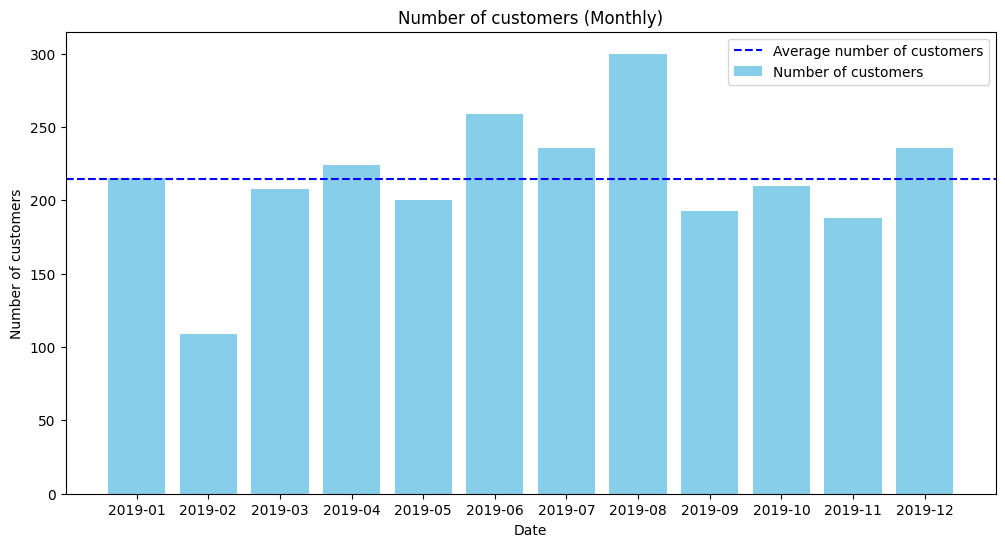

In [16]:
plt.figure(figsize=(12, 6))

plt.bar(amount_of_customers['Transaction_Date'].astype(str), amount_of_customers['Unique_Customers_Count'], label='Number of customers', color='skyblue')
plt.axhline(y=amount_of_customers['Unique_Customers_Count'].mean(), color='blue', linestyle='--', label='Average number of customers')

plt.legend()
plt.ylabel('Number of customers')
plt.xlabel('Date')
plt.title('Number of customers (Monthly)')



plt.show()

In [17]:

base_rate_of_increase = amount_of_customers['Unique_Customers_Count'].iloc[-1] - amount_of_customers['Unique_Customers_Count'].iloc[0]
base_rate_of_growth = (amount_of_customers['Unique_Customers_Count'].iloc[-1] - amount_of_customers['Unique_Customers_Count'].iloc[0])/amount_of_customers['Unique_Customers_Count'].iloc[0]
average_chain_based_rate_of_increase = (amount_of_customers['Unique_Customers_Count'].iloc[-1] - amount_of_customers['Unique_Customers_Count'].iloc[0])/(len(amount_of_customers)-1)
average_chain_based_rate_of_growth = base_rate_of_growth ** (1/(len(amount_of_customers)-1))



retention_of_customers = pd.DataFrame([{'The base rate of increase': base_rate_of_increase, 'The base rate of growth': base_rate_of_growth,
                                       'The average chain-based rate of increase': average_chain_based_rate_of_increase, 'The average chain-based rate of growth': average_chain_based_rate_of_growth}])


retention_of_customers = retention_of_customers.T
retention_of_customers.columns = ['Values']


retention_of_customers.round(3)

,Values
The base rate of increase,21.000
The base rate of growth,0.098
The average chain-based rate of increase,1.909
The average chain-based rate of growth,0.809


In [18]:

analysis_set['Cohort_Month'] = analysis_set.groupby('CustomerID')['Transaction_Date'].transform('min').dt.to_period('M')


analysis_set['Transaction_Month'] = analysis_set['Transaction_Date'].dt.to_period('M')


analysis_set['User_Type'] = np.where(analysis_set['Transaction_Month'] == analysis_set['Cohort_Month'], 'New', 'Old')


user_type = analysis_set.groupby(['Transaction_Month', 'User_Type']).agg(
    Unique_Customers_Count=('CustomerID', 'nunique'),
    Total_Invoice_Amount=('Invoice_amount', 'sum')
).reset_index()

user_type


,Transaction_Month,User_Type,Unique_Customers_Count,Total_Invoice_Amount
0,2019-01,New,215,293330.40831
1,2019-02,New,96,185860.18424
2,2019-02,Old,13,26664.13378
3,2019-03,New,177,191257.26447
4,2019-03,Old,31,31041.66658
5,2019-04,New,163,172678.63041
6,2019-04,Old,61,131311.89072
7,2019-05,New,112,139592.34606
8,2019-05,Old,88,77835.96648
9,2019-06,New,137,134715.40995


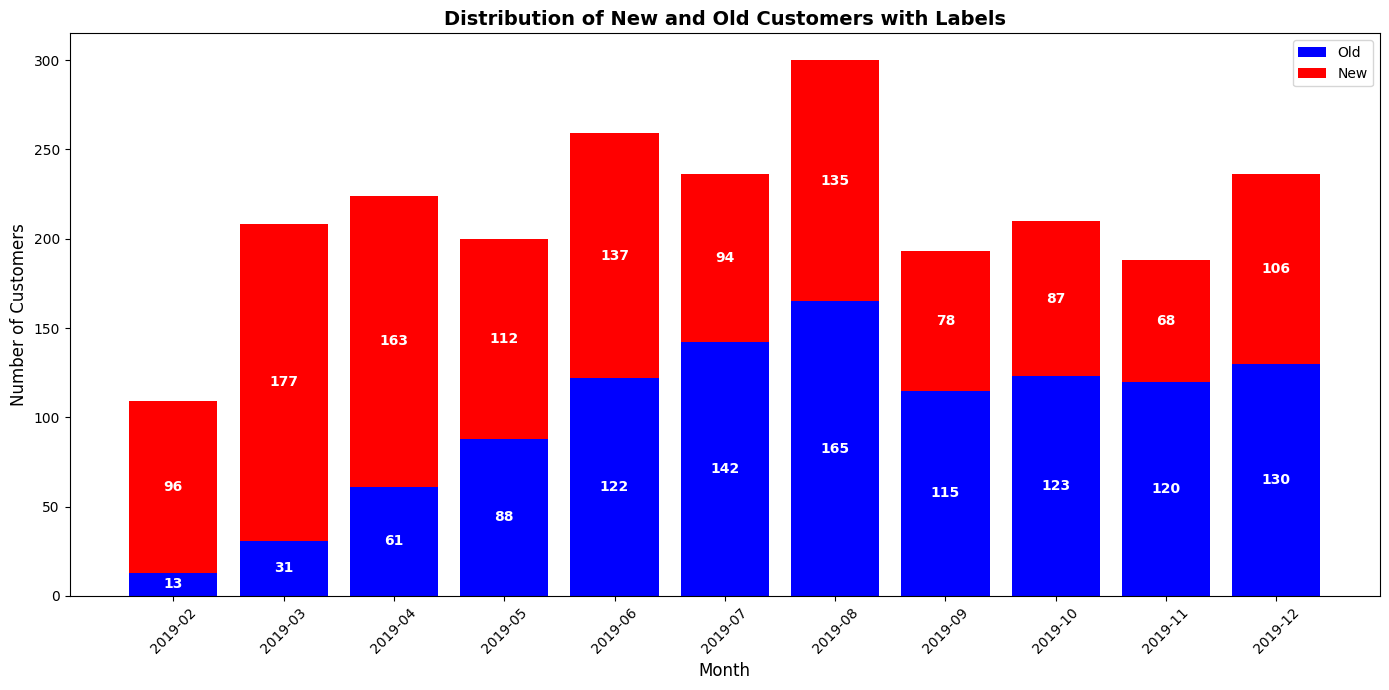

In [19]:
plot_data = user_type.pivot(index='Transaction_Month', columns='User_Type', values='Unique_Customers_Count')
plot_data.index = plot_data.index.astype(str)


plot_data = plot_data.fillna(0).sort_index()


plot_data = plot_data.iloc[1:]


fig, ax = plt.subplots(figsize=(14, 7))


bar1 = ax.bar(plot_data.index, plot_data['Old'], label='Old', color='blue')
bar2 = ax.bar(plot_data.index, plot_data['New'], bottom=plot_data['Old'], label='New', color='red')


ax.bar_label(bar1, label_type='center', color='white', weight='bold', fmt=lambda x: f'{int(x)}' if x > 0 else '')
ax.bar_label(bar2, label_type='center', color='white', weight='bold', fmt=lambda x: f'{int(x)}' if x > 0 else '')


ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.set_title('Distribution of New and Old Customers with Labels', fontsize=14, weight='bold')


plt.xticks(rotation=45)
ax.legend()

plt.tight_layout()
plt.show()


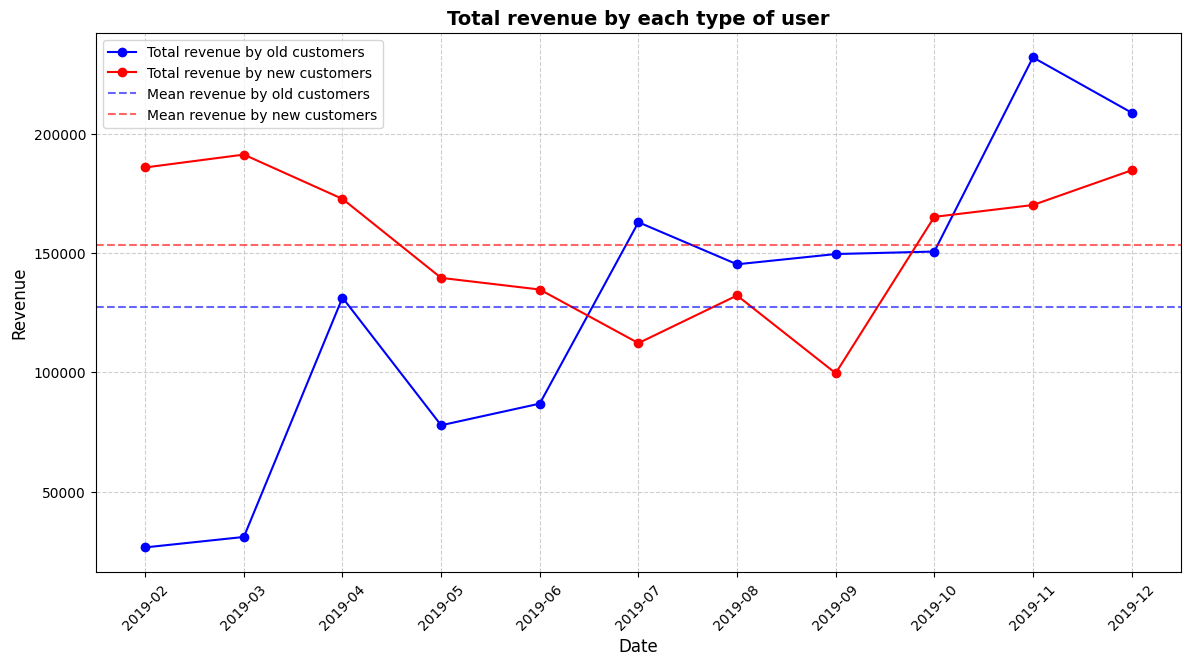

In [20]:
plt.figure(figsize=(14, 7))

old_revenue = user_type[user_type['User_Type'] == 'Old']
new_revenue = user_type[user_type['User_Type'] == 'New'].iloc[1:]

plt.plot(old_revenue['Transaction_Month'].astype('str'), old_revenue['Total_Invoice_Amount'], label = 'Total revenue by old customers', color = 'blue', marker = 'o')
plt.plot(new_revenue['Transaction_Month'].astype('str'), new_revenue['Total_Invoice_Amount'], label = 'Total revenue by new customers', color = 'red', marker = 'o')
plt.axhline(y=old_revenue['Total_Invoice_Amount'].mean(), color = 'blue', linestyle = '--', alpha = 0.6, label = 'Mean revenue by old customers')
plt.axhline(y=new_revenue['Total_Invoice_Amount'].mean(), color = 'red', linestyle = '--', alpha = 0.6, label = 'Mean revenue by new customers')

plt.title('Total revenue by each type of user', fontsize = 14, weight = 'bold')
plt.xlabel('Date', fontsize = 12)
plt.ylabel('Revenue', fontsize = 12)
plt.legend()
plt.grid(alpha = 0.6, linestyle = '--')
plt.xticks(rotation = 45)

plt.show()


In [21]:
revenue_by_month = analysis_set.groupby('Transaction_Month', as_index=False)['Invoice_amount'].sum()
revenue_by_month

,Transaction_Month,Invoice_amount
0,2019-01,293330.40831
1,2019-02,212524.31802
2,2019-03,222298.93105
3,2019-04,303990.52113
4,2019-05,217428.31254
5,2019-06,221623.44619
6,2019-07,275165.19962
7,2019-08,277502.18088
8,2019-09,249221.29464
9,2019-10,315778.82334


In [22]:

user_type = user_type.merge(revenue_by_month, on='Transaction_Month', how='left')


user_type = user_type.rename(columns={
    'Invoice_amount': 'Month_Total_Revenue',
    'Total_Invoice_Amount': 'Segment_Revenue'
})


user_type


,Transaction_Month,User_Type,Unique_Customers_Count,Segment_Revenue,Month_Total_Revenue
0,2019-01,New,215,293330.40831,293330.40831
1,2019-02,New,96,185860.18424,212524.31802
2,2019-02,Old,13,26664.13378,212524.31802
3,2019-03,New,177,191257.26447,222298.93105
4,2019-03,Old,31,31041.66658,222298.93105
5,2019-04,New,163,172678.63041,303990.52113
6,2019-04,Old,61,131311.89072,303990.52113
7,2019-05,New,112,139592.34606,217428.31254
8,2019-05,Old,88,77835.96648,217428.31254
9,2019-06,New,137,134715.40995,221623.44619


In [23]:
user_type['Segment_Revenue_Share(%)'] = user_type['Segment_Revenue'] / user_type['Month_Total_Revenue'] * 100
user_type['Segment_Revenue_Share(%)'] = user_type['Segment_Revenue_Share(%)'].round(2).astype(str) + '%'
user_type

,Transaction_Month,User_Type,Unique_Customers_Count,Segment_Revenue,Month_Total_Revenue,Segment_Revenue_Share(%)
0,2019-01,New,215,293330.40831,293330.40831,100.0%
1,2019-02,New,96,185860.18424,212524.31802,87.45%
2,2019-02,Old,13,26664.13378,212524.31802,12.55%
3,2019-03,New,177,191257.26447,222298.93105,86.04%
4,2019-03,Old,31,31041.66658,222298.93105,13.96%
5,2019-04,New,163,172678.63041,303990.52113,56.8%
6,2019-04,Old,61,131311.89072,303990.52113,43.2%
7,2019-05,New,112,139592.34606,217428.31254,64.2%
8,2019-05,Old,88,77835.96648,217428.31254,35.8%
9,2019-06,New,137,134715.40995,221623.44619,60.79%


<Figure size 1400x700 with 0 Axes>

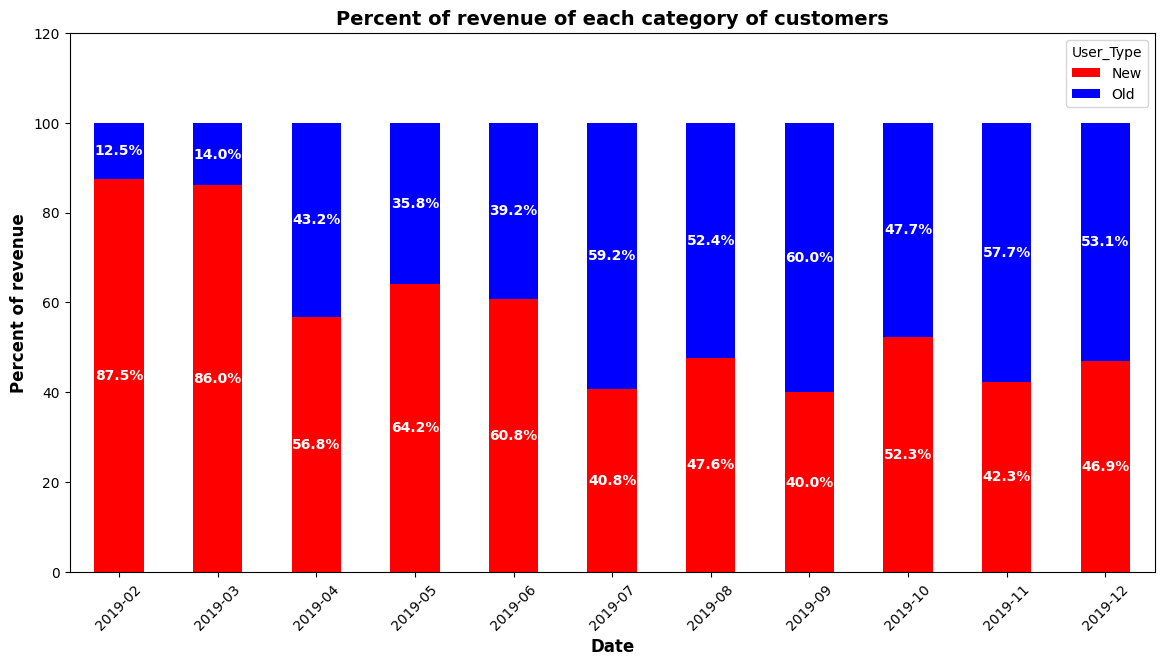

In [24]:
plot_data = user_type.pivot(index='Transaction_Month', columns='User_Type', values='Segment_Revenue_Share(%)')

for col in ['Old', 'New']:
    if col in plot_data.columns:
        plot_data[col] = plot_data[col].astype(str).str.replace('%', '', regex=False).astype(float)

plot_data = plot_data.iloc[1:]
plot_data.index = plot_data.index.astype('str')

plt.figure(figsize=(14, 7))

ax = plot_data.plot(kind='bar', stacked=True, figsize=(14, 7), color=['red', 'blue'])

for container in ax.containers:

    labels = [f'{val.get_height():.1f}%' if val.get_height() > 0 else '' for val in container]


    ax.bar_label(container, labels=labels, label_type='center', color='white', fontweight='bold', fontsize=10)

plt.ylim(0, 120)
plt.xticks(rotation = 45)
plt.ylabel('Percent of revenue', fontsize = 12, fontweight = 'bold')
plt.xlabel('Date', fontsize = 12, fontweight = 'bold')
plt.title('Percent of revenue of each category of customers', fontsize = 14, fontweight = 'bold')

plt.show()

In [25]:
discount_revenue_analysis = pd.DataFrame()
discount_revenue_analysis['Discount'] = analysis_set['Discount_pct'] * analysis_set['Disc_Status']
discount_revenue_analysis['Revenue'] = analysis_set['Invoice_amount']

discount_revenue_analysis.groupby('Discount')['Revenue'].agg(
    Total_profit = 'sum',
    Number_of_orders = 'count',
    Average_profit = 'mean'
).round(2).reset_index()

,Discount,Total_profit,Number_of_orders,Average_profit
0,0.0,2443787.61,35146,69.53
1,10.0,357017.06,5933,60.17
2,20.0,310918.09,6000,51.82
3,30.0,272734.25,5845,46.66


In [26]:

discount_corr_analysis = pd.DataFrame()
discount_corr_analysis['Customer_ID'] = analysis_set['CustomerID']
discount_corr_analysis['Discount_pct'] = analysis_set['Discount_pct']
discount_corr_analysis['Disc_status'] = analysis_set['Disc_Status']
discount_corr_analysis['Invoice_amount'] = analysis_set['Invoice_amount']


discount_corr_analysis

,Customer_ID,Discount_pct,Disc_status,Invoice_amount
0,17850,10.0,1,118.65510
1,17850,10.0,1,118.65510
2,17850,10.0,1,-4.65500
3,17850,10.0,0,66.54300
4,17850,10.0,1,6.84700
...,...,...,...,...
52919,14410,30.0,0,103.32000
52920,14410,30.0,1,22.75008
52921,14410,30.0,1,89.83440
52922,14600,30.0,0,356.49000


In [27]:
discount_corr_analysis = discount_corr_analysis.groupby('Customer_ID').agg(
    Number_of_orders = ('Customer_ID', 'count'),
    Percent_of_discount_usage = ('Disc_status', 'mean'),
    Total_profit = ('Invoice_amount', 'sum'),
    Average_profit = ('Invoice_amount', 'mean')
).round(2).reset_index()

discount_corr_analysis

,Customer_ID,Number_of_orders,Percent_of_discount_usage,Total_profit,Average_profit
0,12346,2,1.00,-128.31,-64.15
1,12347,60,0.33,10475.44,174.59
2,12348,23,0.48,961.47,41.80
3,12350,17,0.35,964.05,56.71
4,12356,36,0.31,506.94,14.08
...,...,...,...,...,...
1463,18259,7,0.43,235.57,33.65
1464,18260,40,0.40,1310.59,32.76
1465,18269,8,0.38,37.47,4.68
1466,18277,1,0.00,262.80,262.80


In [28]:
discount_corr_analysis['Discount_Frequency'] = pd.cut(
    discount_corr_analysis['Percent_of_discount_usage'],
    bins=[-0.01, 0.00, 0.50, 0.99, 1.00],
    labels=['Never', 'Sometimes', 'Usually', 'Always']
)

discount_corr_analysis

,Customer_ID,Number_of_orders,Percent_of_discount_usage,Total_profit,Average_profit,Discount_Frequency
0,12346,2,1.00,-128.31,-64.15,Always
1,12347,60,0.33,10475.44,174.59,Sometimes
2,12348,23,0.48,961.47,41.80,Sometimes
3,12350,17,0.35,964.05,56.71,Sometimes
4,12356,36,0.31,506.94,14.08,Sometimes
...,...,...,...,...,...,...
1463,18259,7,0.43,235.57,33.65,Sometimes
1464,18260,40,0.40,1310.59,32.76,Sometimes
1465,18269,8,0.38,37.47,4.68,Sometimes
1466,18277,1,0.00,262.80,262.80,Never


In [29]:
profit_analysis = discount_corr_analysis.groupby('Discount_Frequency').agg(
    Number_of_customers=('Customer_ID', 'count'),
    Number_of_orders = ('Number_of_orders', 'sum'),
    Average_number_of_orders = ('Number_of_orders', 'mean'),
    Total_group_profit=('Total_profit', 'sum'),
    Average_customer_profit=('Average_profit', 'mean')
).round(2).reset_index()

profit_analysis


/tmp/ipykernel_2346/2436490801.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  profit_analysis = discount_corr_analysis.groupby('Discount_Frequency').agg(


,Discount_Frequency,Number_of_customers,Number_of_orders,Average_number_of_orders,Total_group_profit,Average_customer_profit
0,Never,94,226,2.40,16640.82,75.51
1,Sometimes,1257,51630,41.07,3302283.22,63.24
2,Usually,89,1031,11.58,64451.50,57.46
3,Always,28,37,1.32,1081.33,26.91


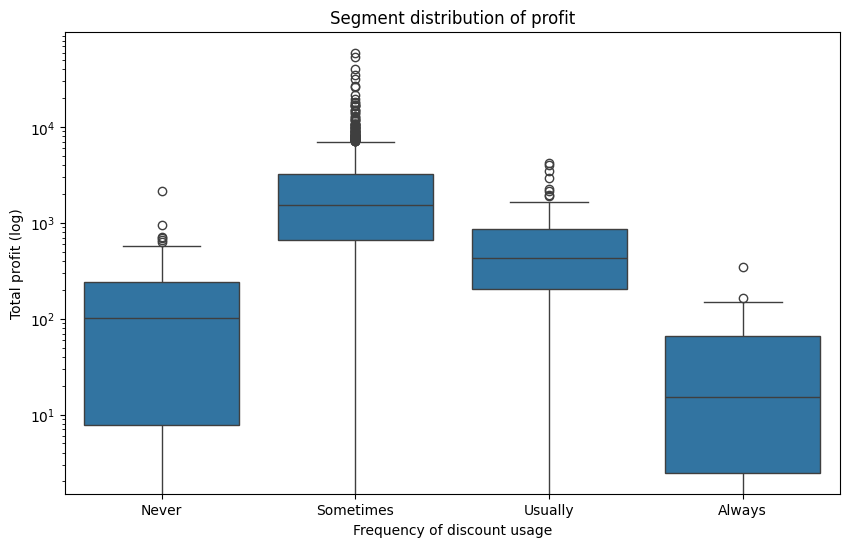

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))
sns.boxplot(data=discount_corr_analysis, x='Discount_Frequency', y='Total_profit')
plt.yscale('log')
plt.title('Segment distribution of profit')
plt.xlabel('Frequency of discount usage')
plt.ylabel('Total profit (log)')
plt.show()


In [31]:
from scipy import stats


x = discount_corr_analysis['Percent_of_discount_usage']
y = discount_corr_analysis['Total_profit']


p_val_x = stats.normaltest(x)[1]
p_val_y = stats.normaltest(y)[1]

alpha = 0.05
print(f"p-value Percent_of_discount_usage: {p_val_x:.5f}")
print(f"p-Total_profit: {p_val_y:.5f}")


if p_val_x > alpha and p_val_y > alpha:
    corr_type = 'Pearson'
    corr_coef, p_corr = stats.pearsonr(x, y)
else:
    corr_type = 'Spearman'
    corr_coef, p_corr = stats.spearmanr(x, y)

print(f"\nMethod used: {corr_type}")
print(f"Correlation ratio: {corr_coef:.4f}")
print(f"Statistical significance (p-value): {p_corr:.5f}")


p-value Percent_of_discount_usage: 0.00000
p-Total_profit: 0.00000

Method used: Spearman
Correlation ratio: 0.0172
Statistical significance (p-value): 0.50903


In [32]:
x = discount_corr_analysis['Percent_of_discount_usage']
y = discount_corr_analysis['Number_of_orders']


p_val_x = stats.normaltest(x)[1]
p_val_y = stats.normaltest(y)[1]

alpha = 0.05
print(f"p-value Percent_of_discount_usage: {p_val_x:.5f}")
print(f"p-Number_of_orders: {p_val_y:.5f}")


if p_val_x > alpha and p_val_y > alpha:
    corr_type = 'Pearson'
    corr_coef, p_corr = stats.pearsonr(x, y)
else:
    corr_type = 'Spearman'
    corr_coef, p_corr = stats.spearmanr(x, y)

print(f"\nMethod used: {corr_type}")
print(f"Correlation ratio: {corr_coef:.4f}")
print(f"Statistical significance (p-value): {p_corr:.5f}")

p-value Percent_of_discount_usage: 0.00000
p-Number_of_orders: 0.00000

Method used: Spearman
Correlation ratio: 0.0325
Statistical significance (p-value): 0.21305


In [33]:
x = discount_corr_analysis['Percent_of_discount_usage']
y = discount_corr_analysis['Average_profit']


p_val_x = stats.normaltest(x)[1]
p_val_y = stats.normaltest(y)[1]

alpha = 0.05
print(f"p-value Percent_of_discount_usage: {p_val_x:.5f}")
print(f"p-Average_profit: {p_val_y:.5f}")


if p_val_x > alpha and p_val_y > alpha:
    corr_type = 'Pearson'
    corr_coef, p_corr = stats.pearsonr(x, y)
else:
    corr_type = 'Spearman'
    corr_coef, p_corr = stats.spearmanr(x, y)

print(f"\nMethod used: {corr_type}")
print(f"Correlation ratio: {corr_coef:.4f}")
print(f"Statistical significance (p-value): {p_corr:.5f}")

p-value Percent_of_discount_usage: 0.00000
p-Average_profit: 0.00000

Method used: Spearman
Correlation ratio: -0.0393
Statistical significance (p-value): 0.13189


In [34]:
analysis_set

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,...,Coupon_Code,Discount_pct,Disc_Status,Revenue,EBIT,GST_value,Invoice_amount,Cohort_Month,Transaction_Month,User_Type
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.50,Used,...,ELEC10,10.0,1,153.71,131.839,13.18390,118.65510,2019-01,2019-01,New
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.50,Used,...,ELEC10,10.0,1,153.71,131.839,13.18390,118.65510,2019-01,2019-01,New
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.50,Used,...,OFF10,10.0,1,2.05,-4.655,0.00000,-4.65500,2019-01,2019-01,New
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.50,Not Used,...,SALE10,10.0,0,87.65,81.150,14.60700,66.54300,2019-01,2019-01,New
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.50,Used,...,AIO10,10.0,1,16.50,8.350,1.50300,6.84700,2019-01,2019-01,New
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52919,14410,48493,2019-12-31,GGOENEBB078899,Nest Cam Indoor Security Camera - USA,Nest-USA,1,121.30,6.50,Clicked,...,ELEC30,30.0,0,121.30,114.800,11.48000,103.32000,2019-12,2019-12,New
52920,14410,48494,2019-12-31,GGOEGAEB091117,Google Zip Hoodie Black,Apparel,1,48.92,6.50,Used,...,SALE30,30.0,1,48.92,27.744,4.99392,22.75008,2019-12,2019-12,New
52921,14410,48495,2019-12-31,GGOENEBQ084699,Nest Learning Thermostat 3rd Gen-USA - White,Nest-USA,1,151.88,6.50,Used,...,ELEC30,30.0,1,151.88,99.816,9.98160,89.83440,2019-12,2019-12,New
52922,14600,48496,2019-12-31,GGOENEBQ079199,Nest Protect Smoke + CO White Wired Alarm-USA,Nest-USA,5,80.52,6.50,Clicked,...,ELEC30,30.0,0,402.60,396.100,39.61000,356.49000,2019-12,2019-12,New


In [35]:
analysis_set['Revenue'] = analysis_set['Quantity'] * analysis_set['Avg_Price']
analysis_set['EBIT'] = (analysis_set['Revenue'] - analysis_set['Revenue'] * (analysis_set['Discount_pct'] * analysis_set['Disc_Status'] / 100)) - analysis_set['Delivery_Charges']

product_category_analysis = analysis_set



In [36]:
product_category_analysis = product_category_analysis.groupby('Product_Category').agg(
    Number_of_orders = ('Transaction_ID', 'count'),
    Number_of_customers = ('CustomerID', 'nunique'),
    Total_revenue = ('Revenue', 'sum'),
    Avearge_revenue = ('Revenue', 'mean'),
    Total_EBIT = ('EBIT', 'sum'),
    Average_EBIT = ('EBIT', 'mean'),
    Total_profit = ('Invoice_amount', 'sum'),
    Average_profit = ('Invoice_amount', 'mean')
    ).round(2).reset_index()

product_category_analysis

,Product_Category,Number_of_orders,Number_of_customers,Total_revenue,Avearge_revenue,Total_EBIT,Average_EBIT,Total_profit,Average_profit
0,Accessories,234,150,7295.88,31.18,3950.93,16.88,3452.70,14.76
1,Android,43,42,711.03,16.54,314.79,7.32,275.78,6.41
2,Apparel,18126,1323,591145.80,32.61,374800.62,20.68,301823.33,16.65
3,Backpacks,89,75,8772.69,98.57,7609.77,85.50,6846.09,76.92
4,Bags,1882,728,151314.43,80.40,116712.21,62.01,94890.15,50.42
5,Bottles,268,203,6923.65,25.83,2844.88,10.62,2651.86,9.90
6,Drinkware,3483,919,200707.83,57.62,138425.88,39.74,111591.24,32.04
7,Fun,160,118,6029.01,37.68,4148.70,25.93,3300.44,20.63
8,Gift Cards,159,77,19533.82,122.85,18521.38,116.49,17595.31,110.66
9,Google,105,89,9420.47,89.72,6614.18,62.99,5906.58,56.25


In [37]:
product_category_analysis['EBIT_margin'] = product_category_analysis['Total_EBIT'] / product_category_analysis['Total_revenue']
product_category_analysis['EBIT_margin'] = product_category_analysis['EBIT_margin'].round(2)

product_category_analysis['Net_profit_margin'] = product_category_analysis['Total_profit'] / product_category_analysis['Total_revenue']
product_category_analysis['Net_profit_margin'] = product_category_analysis['Net_profit_margin'].round(2)

product_category_analysis['Share_of_total_revenue_(%)'] = product_category_analysis['Total_revenue'] / product_category_analysis['Total_revenue'].sum() * 100
product_category_analysis['Share_of_total_EBIT_(%)'] = product_category_analysis['Total_EBIT'] / product_category_analysis['Total_EBIT'].sum() * 100
product_category_analysis['Share_of_total_profit_(%)'] = product_category_analysis['Total_profit'] / product_category_analysis['Total_profit'].sum() * 100

product_category_analysis

,Product_Category,Number_of_orders,Number_of_customers,Total_revenue,Avearge_revenue,Total_EBIT,Average_EBIT,Total_profit,Average_profit,EBIT_margin,Net_profit_margin,Share_of_total_revenue_(%),Share_of_total_EBIT_(%),Share_of_total_profit_(%)
0,Accessories,234,150,7295.88,31.18,3950.93,16.88,3452.70,14.76,0.54,0.47,0.156202,0.103879,0.102016
1,Android,43,42,711.03,16.54,314.79,7.32,275.78,6.41,0.44,0.39,0.015223,0.008277,0.008148
2,Apparel,18126,1323,591145.80,32.61,374800.62,20.68,301823.33,16.65,0.63,0.51,12.656215,9.854391,8.917925
3,Backpacks,89,75,8772.69,98.57,7609.77,85.50,6846.09,76.92,0.87,0.78,0.187820,0.200079,0.202280
4,Bags,1882,728,151314.43,80.40,116712.21,62.01,94890.15,50.42,0.77,0.63,3.239586,3.068639,2.803704
5,Bottles,268,203,6923.65,25.83,2844.88,10.62,2651.86,9.90,0.41,0.38,0.148233,0.074799,0.078354
6,Drinkware,3483,919,200707.83,57.62,138425.88,39.74,111591.24,32.04,0.69,0.56,4.297081,3.639542,3.297168
7,Fun,160,118,6029.01,37.68,4148.70,25.93,3300.44,20.63,0.69,0.55,0.129079,0.109079,0.097518
8,Gift Cards,159,77,19533.82,122.85,18521.38,116.49,17595.31,110.66,0.95,0.90,0.418212,0.486971,0.519886
9,Google,105,89,9420.47,89.72,6614.18,62.99,5906.58,56.25,0.70,0.63,0.201689,0.173902,0.174521


In [38]:
margin_analysis = product_category_analysis[['Product_Category', 'Net_profit_margin']].sort_values(by = 'Net_profit_margin', ascending=False)
margin_analysis['Assessment_of_margin'] = np.linspace(20, 1, 20)
product_category_analysis['Assessment_of_margin'] = margin_analysis['Assessment_of_margin']

margin_analysis

,Product_Category,Net_profit_margin,Assessment_of_margin
8,Gift Cards,0.90,20.0
14,Nest,0.85,19.0
15,Nest-Canada,0.81,18.0
16,Nest-USA,0.80,17.0
3,Backpacks,0.78,16.0
17,Notebooks & Journals,0.76,15.0
10,Headgear,0.72,14.0
13,More Bags,0.68,13.0
9,Google,0.63,12.0
4,Bags,0.63,11.0


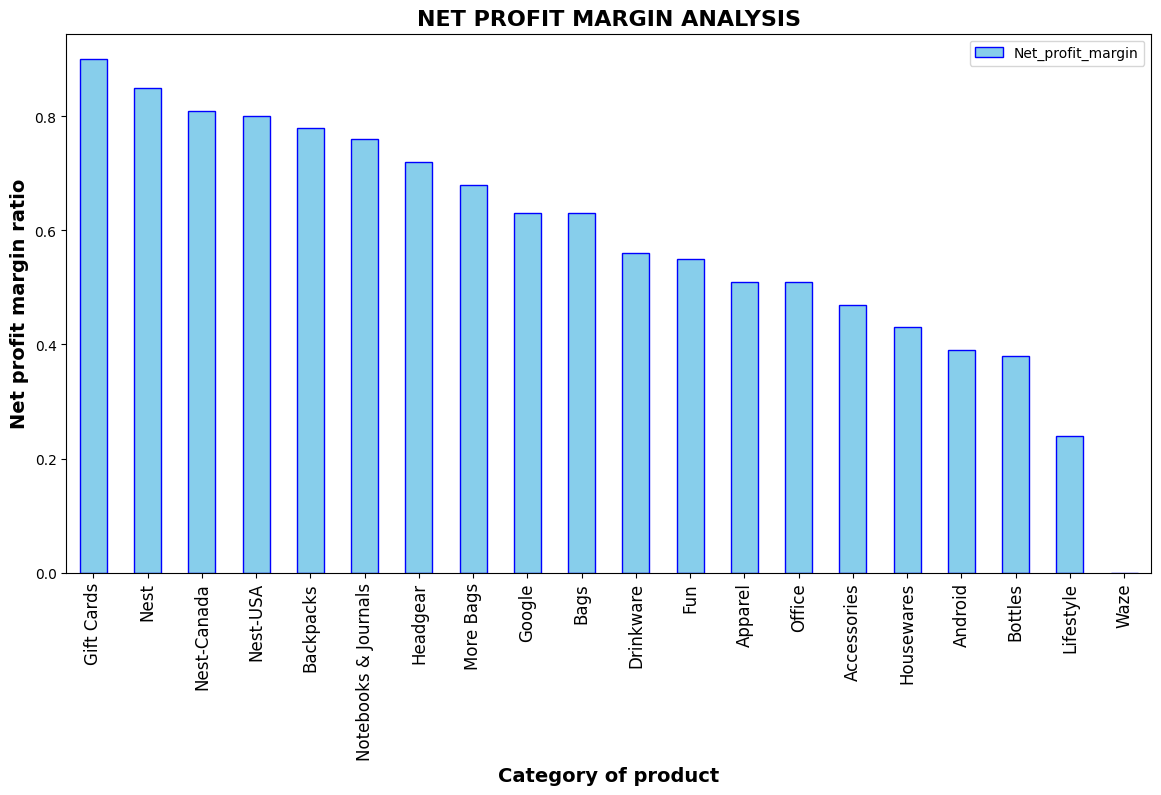

In [39]:
margin_analysis.plot(
    kind='bar',
    x='Product_Category',
    y='Net_profit_margin',
    stacked=False,
    figsize=(14, 7),
    color='skyblue',
    edgecolor='blue'
)


plt.title('NET PROFIT MARGIN ANALYSIS', fontsize=16, weight='bold')
plt.xlabel('Category of product', fontsize=14, weight='bold')
plt.ylabel('Net profit margin ratio', fontsize=14, weight='bold')


plt.xticks(fontsize=12)

plt.show()


In [40]:
total_profit_analysis = product_category_analysis[['Product_Category', 'Share_of_total_profit_(%)']].sort_values(by = 'Share_of_total_profit_(%)', ascending = False)
total_profit_analysis['Assessment_of_profit'] = np.linspace(20, 1, 20)
product_category_analysis['Assessment_of_profit'] = total_profit_analysis['Assessment_of_profit']

total_profit_analysis

,Product_Category,Share_of_total_profit_(%),Assessment_of_profit
16,Nest-USA,60.736518,20.0
14,Nest,13.037183,19.0
2,Apparel,8.917925,18.0
18,Office,4.137717,17.0
6,Drinkware,3.297168,16.0
4,Bags,2.803704,15.0
17,Notebooks & Journals,2.403436,14.0
15,Nest-Canada,1.695844,13.0
10,Headgear,1.136613,12.0
12,Lifestyle,0.532948,11.0


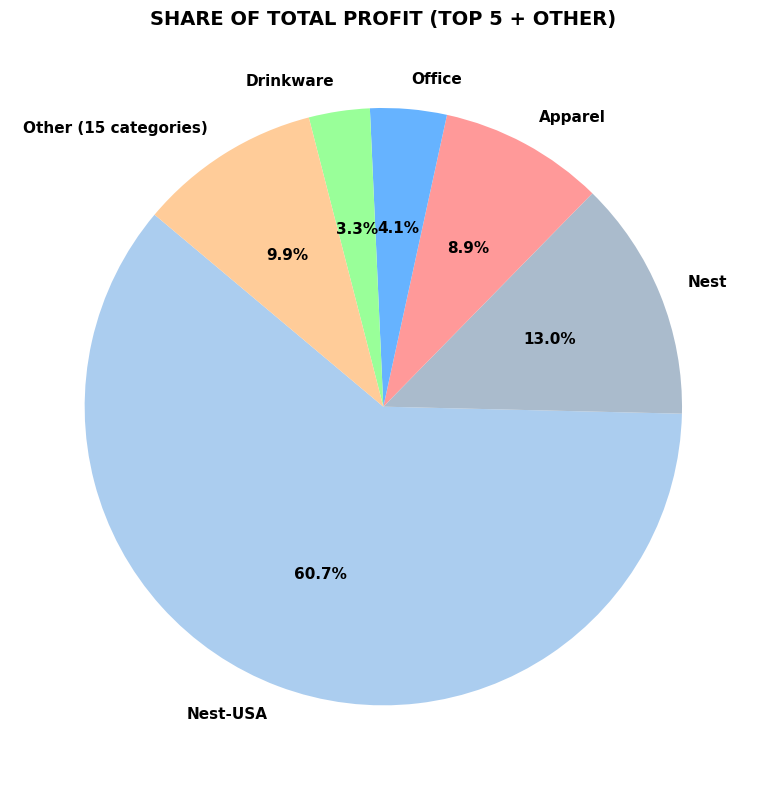

In [41]:
top_5 = total_profit_analysis.head(5).copy()
others_sum = total_profit_analysis['Share_of_total_profit_(%)'].iloc[5:].sum()


pie_data = pd.concat([
    top_5[['Product_Category', 'Share_of_total_profit_(%)']],
    pd.DataFrame([{'Product_Category': 'Other (15 categories)', 'Share_of_total_profit_(%)': others_sum}])
], ignore_index=True)


plt.figure(figsize=(8, 8))
plt.pie(
    pie_data['Share_of_total_profit_(%)'],
    labels=pie_data['Product_Category'],
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 11, 'weight': 'bold'},
    colors=['#abcdef', '#aabbcc', '#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
)

plt.title('SHARE OF TOTAL PROFIT (TOP 5 + OTHER)', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

In [42]:
number_of_customers_analysis = product_category_analysis[['Product_Category', 'Number_of_customers']].sort_values(by='Number_of_customers', ascending=False)

number_of_customers_analysis['Number_of_customers_assessment'] = np.linspace(20, 1, 20)
product_category_analysis['Number_of_customers_assessment'] = number_of_customers_analysis['Number_of_customers_assessment']
number_of_customers_analysis

,Product_Category,Number_of_customers,Number_of_customers_assessment
2,Apparel,1323,20.0
16,Nest-USA,1260,19.0
18,Office,1103,18.0
6,Drinkware,919,17.0
12,Lifestyle,817,16.0
4,Bags,728,15.0
14,Nest,516,14.0
10,Headgear,425,13.0
17,Notebooks & Journals,383,12.0
19,Waze,309,11.0


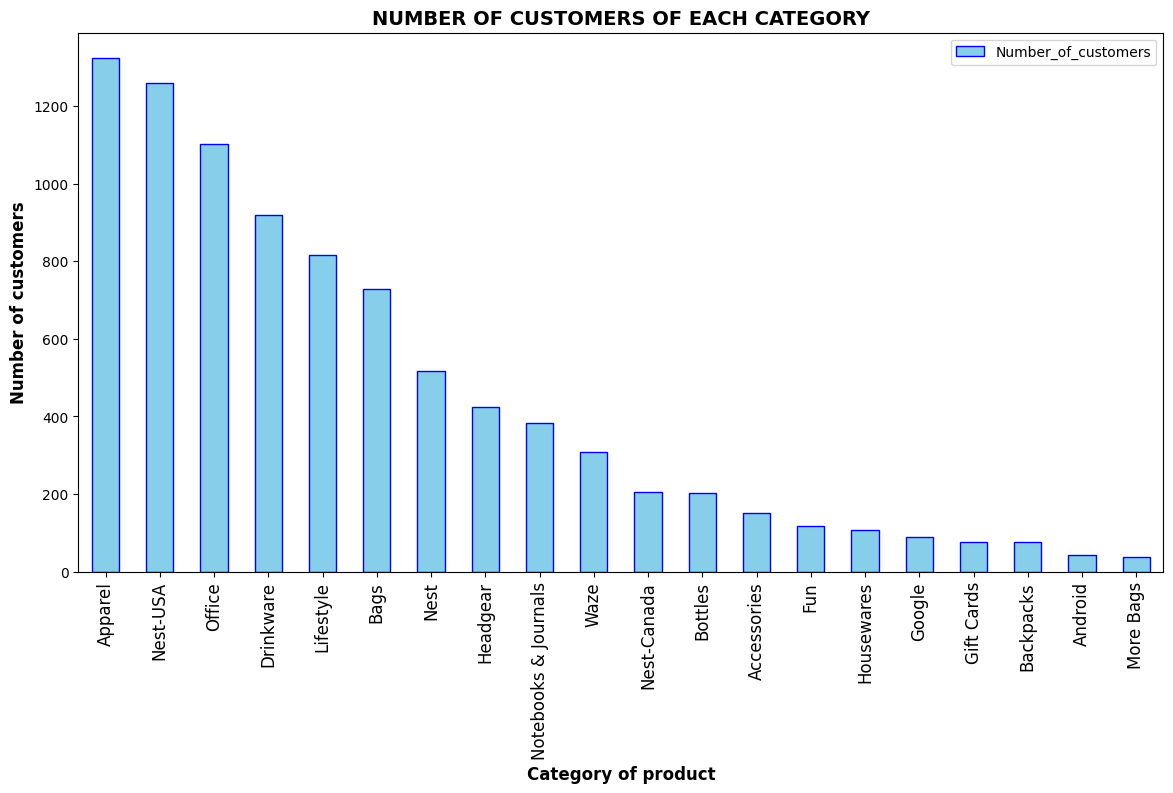

In [43]:
number_of_customers_analysis.plot(
    kind = 'bar',
    figsize=(14, 7),
    x = 'Product_Category',
    y = 'Number_of_customers',
    color = 'skyblue',
    edgecolor = 'blue'
)

plt.title('NUMBER OF CUSTOMERS OF EACH CATEGORY', weight = 'bold', fontsize = 14)
plt.xlabel('Category of product', weight = 'bold', fontsize=12)
plt.ylabel('Number of customers', weight = 'bold', fontsize=12)
plt.xticks(fontsize=12)


plt.show()

In [44]:
number_of_orders_analysis = product_category_analysis[['Product_Category', 'Number_of_orders']].sort_values(by='Number_of_orders', ascending=False)
number_of_orders_analysis['Number_of_orders_assessment'] = np.linspace(20, 1, 20)

product_category_analysis['Number_of_orders_assessment'] = number_of_orders_analysis['Number_of_orders_assessment']
number_of_orders_analysis

,Product_Category,Number_of_orders,Number_of_orders_assessment
2,Apparel,18126,20.0
16,Nest-USA,14013,19.0
18,Office,6513,18.0
6,Drinkware,3483,17.0
12,Lifestyle,3092,16.0
14,Nest,2198,15.0
4,Bags,1882,14.0
10,Headgear,771,13.0
17,Notebooks & Journals,749,12.0
19,Waze,554,11.0


<function matplotlib.pyplot.show(close=None, block=None)>

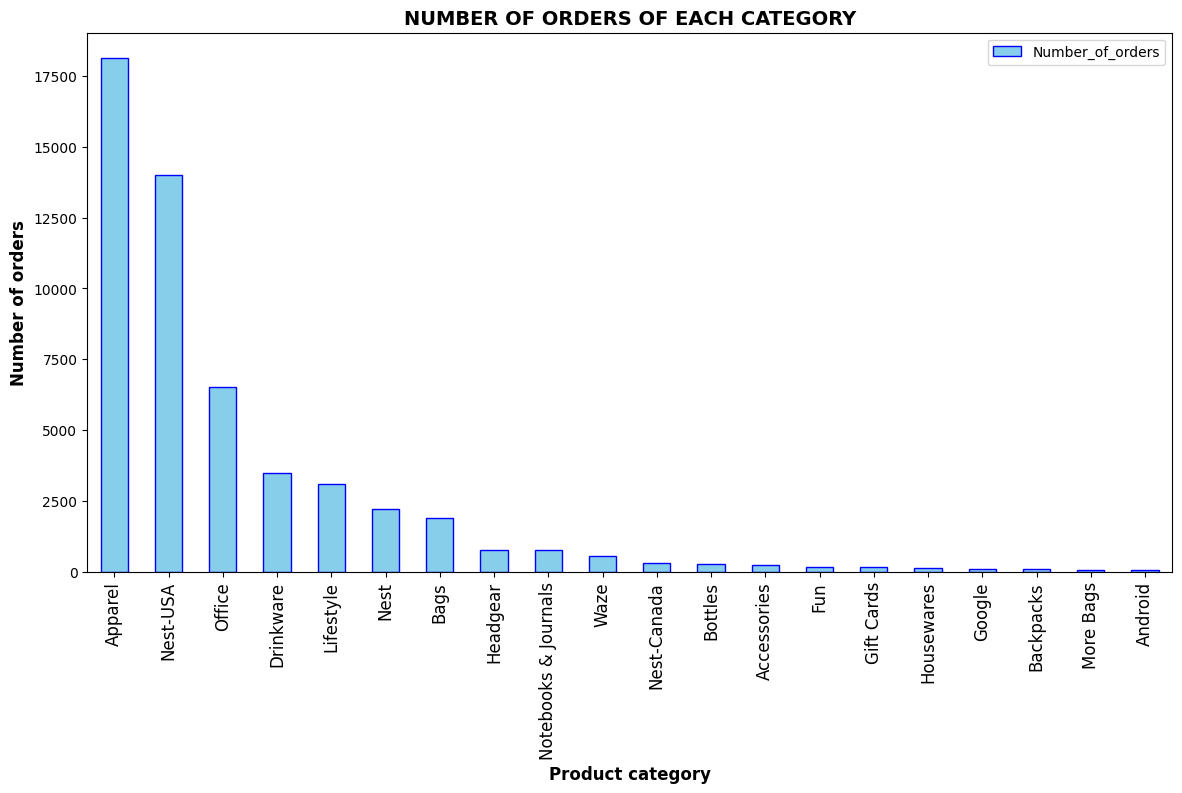

In [45]:
number_of_orders_analysis.plot(
    kind = 'bar',
    figsize=(14, 7),
    x = 'Product_Category',
    y = 'Number_of_orders',
    color = 'skyblue',
    edgecolor = 'blue'
)

plt.title('NUMBER OF ORDERS OF EACH CATEGORY', weight = 'bold', fontsize = 14)
plt.xlabel('Product category', weight = 'bold', fontsize = 12)
plt.ylabel('Number of orders', weight = 'bold', fontsize = 12)
plt.xticks(fontsize = 12)

plt.show

In [46]:
product_category_analysis['Total_assessment_of_category'] = product_category_analysis['Assessment_of_profit'] * 0.6 + product_category_analysis['Assessment_of_margin'] * 0.2 + product_category_analysis['Number_of_customers_assessment'] * 0.1 + product_category_analysis['Number_of_orders_assessment'] * 0.1

In [47]:
total_category_assessment = product_category_analysis[['Product_Category', 'Total_assessment_of_category']].sort_values(by='Total_assessment_of_category', ascending=False)
total_category_assessment

,Product_Category,Total_assessment_of_category
16,Nest-USA,19.2
14,Nest,18.1
2,Apparel,16.4
18,Office,15.2
6,Drinkware,15.0
4,Bags,14.1
17,Notebooks & Journals,13.8
15,Nest-Canada,13.4
10,Headgear,12.6
8,Gift Cards,11.0


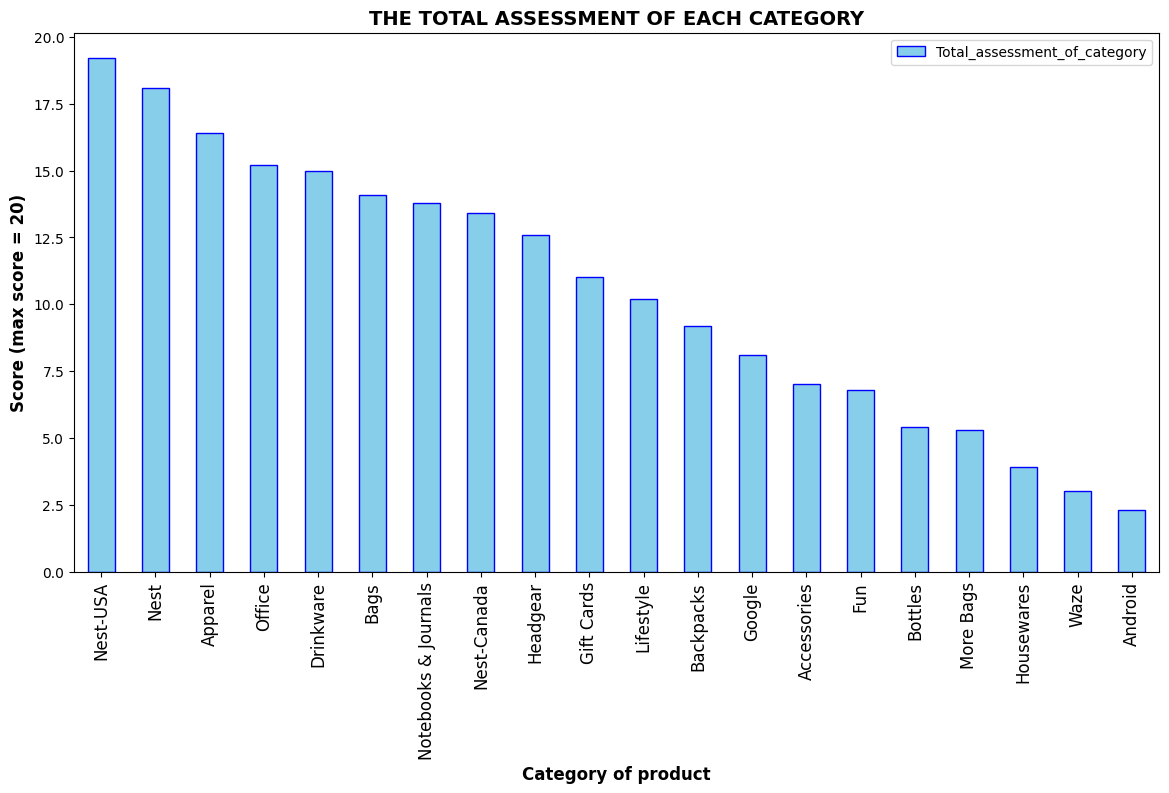

In [48]:
total_category_assessment.plot(
    kind = 'bar',
    figsize=(14, 7),
    x = 'Product_Category',
    y = 'Total_assessment_of_category',
    color = 'skyblue',
    edgecolor = 'blue'
    )

plt.title('THE TOTAL ASSESSMENT OF EACH CATEGORY', weight = 'bold', fontsize = 14)
plt.xlabel('Category of product', weight = 'bold', fontsize = 12)
plt.ylabel('Score (max score = 20)', weight = 'bold', fontsize = 12)
plt.xticks(fontsize = 12)

plt.show()

In [49]:
product_category_analysis['Cohort'] = pd.cut(product_category_analysis['Total_assessment_of_category'], bins = [-1, 5, 15, 20], labels=['The least valuable', 'Valuable', 'The most valuable'])

product_category_analysis.groupby('Cohort')['Product_Category'].unique()

/tmp/ipykernel_2346/2293542740.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  product_category_analysis.groupby('Cohort')['Product_Category'].unique()


,Product_Category
Cohort,
The least valuable,"[Android, Housewares, Waze]"
Valuable,"[Accessories, Backpacks, Bags, Bottles, Drinkw..."
The most valuable,"[Apparel, Nest, Nest-USA, Office]"


In [50]:
analysis_set

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,...,Coupon_Code,Discount_pct,Disc_Status,Revenue,EBIT,GST_value,Invoice_amount,Cohort_Month,Transaction_Month,User_Type
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.50,Used,...,ELEC10,10.0,1,153.71,131.839,13.18390,118.65510,2019-01,2019-01,New
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.50,Used,...,ELEC10,10.0,1,153.71,131.839,13.18390,118.65510,2019-01,2019-01,New
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.50,Used,...,OFF10,10.0,1,2.05,-4.655,0.00000,-4.65500,2019-01,2019-01,New
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.50,Not Used,...,SALE10,10.0,0,87.65,81.150,14.60700,66.54300,2019-01,2019-01,New
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.50,Used,...,AIO10,10.0,1,16.50,8.350,1.50300,6.84700,2019-01,2019-01,New
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52919,14410,48493,2019-12-31,GGOENEBB078899,Nest Cam Indoor Security Camera - USA,Nest-USA,1,121.30,6.50,Clicked,...,ELEC30,30.0,0,121.30,114.800,11.48000,103.32000,2019-12,2019-12,New
52920,14410,48494,2019-12-31,GGOEGAEB091117,Google Zip Hoodie Black,Apparel,1,48.92,6.50,Used,...,SALE30,30.0,1,48.92,27.744,4.99392,22.75008,2019-12,2019-12,New
52921,14410,48495,2019-12-31,GGOENEBQ084699,Nest Learning Thermostat 3rd Gen-USA - White,Nest-USA,1,151.88,6.50,Used,...,ELEC30,30.0,1,151.88,99.816,9.98160,89.83440,2019-12,2019-12,New
52922,14600,48496,2019-12-31,GGOENEBQ079199,Nest Protect Smoke + CO White Wired Alarm-USA,Nest-USA,5,80.52,6.50,Clicked,...,ELEC30,30.0,0,402.60,396.100,39.61000,356.49000,2019-12,2019-12,New


In [51]:
daily_totals = analysis_set.groupby('Transaction_Date')['Transaction_ID'].count().reset_index(name='Number_of_orders')
daily_totals['Day_of_month'] = daily_totals['Transaction_Date'].dt.day
daily_average_orders = daily_totals.groupby('Day_of_month')['Number_of_orders'].mean().round(0).reset_index()
daily_average_orders

,Day_of_month,Number_of_orders
0,1,144.0
1,2,134.0
2,3,144.0
3,4,145.0
4,5,145.0
5,6,156.0
6,7,152.0
7,8,128.0
8,9,134.0
9,10,134.0


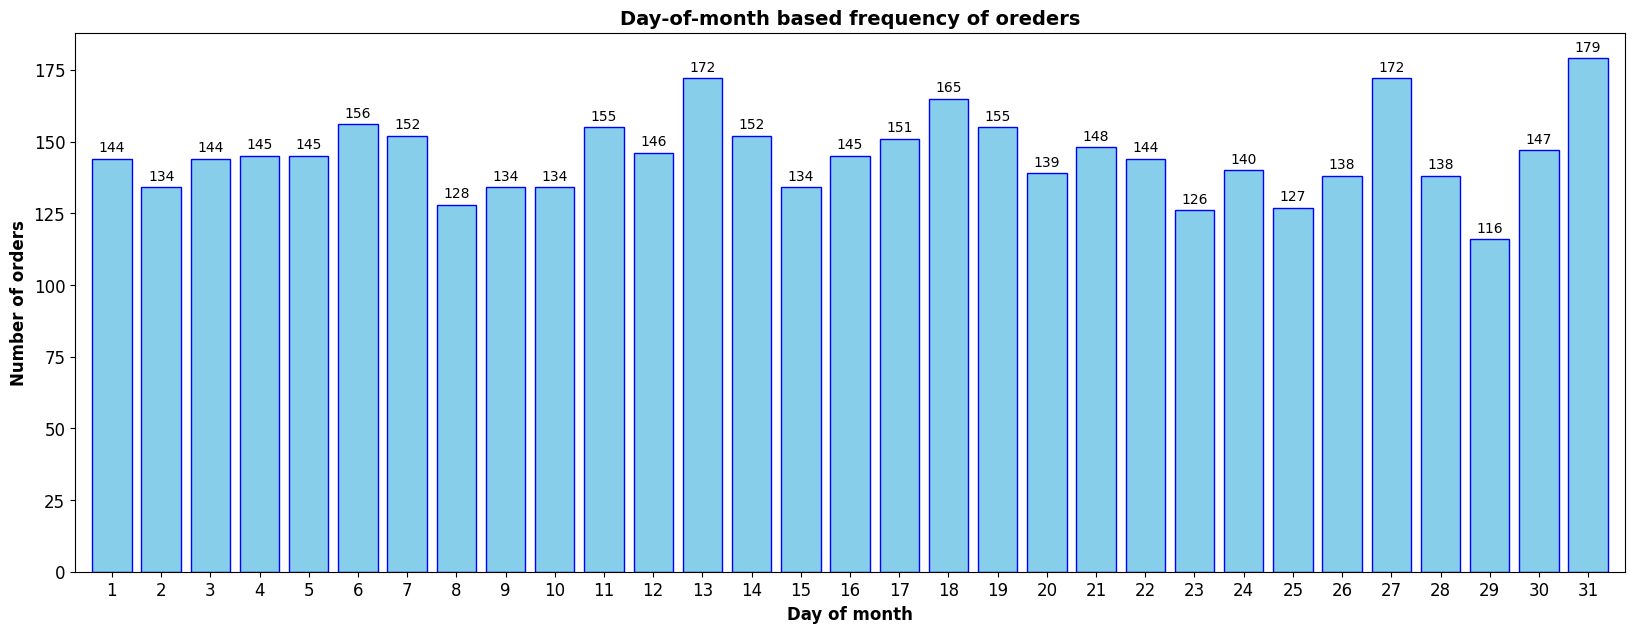

In [52]:
plt.figure(figsize=(20, 7))

bars = plt.bar(
    daily_average_orders['Day_of_month'],
    daily_average_orders['Number_of_orders'],
    color = 'skyblue',
    edgecolor = 'blue'
    )




plt.title('Day-of-month based frequency of oreders', weight = 'bold', fontsize = 14)
plt.ylabel('Number of orders', weight = 'bold', fontsize = 12)
plt.xlabel('Day of month', weight = 'bold', fontsize = 12)
plt.xlim(0.25, 31.75)
plt.xticks(range(1, 32), rotation = 0, fontsize = 12)
plt.yticks(fontsize = 12)

plt.bar_label(bars, fmt='%.0f', padding=3, fontsize=10)


plt.show()

In [53]:
stats.normaltest(daily_average_orders['Number_of_orders'])

NormaltestResult(statistic=np.float64(1.923476271640332), pvalue=np.float64(0.3822279441816923))

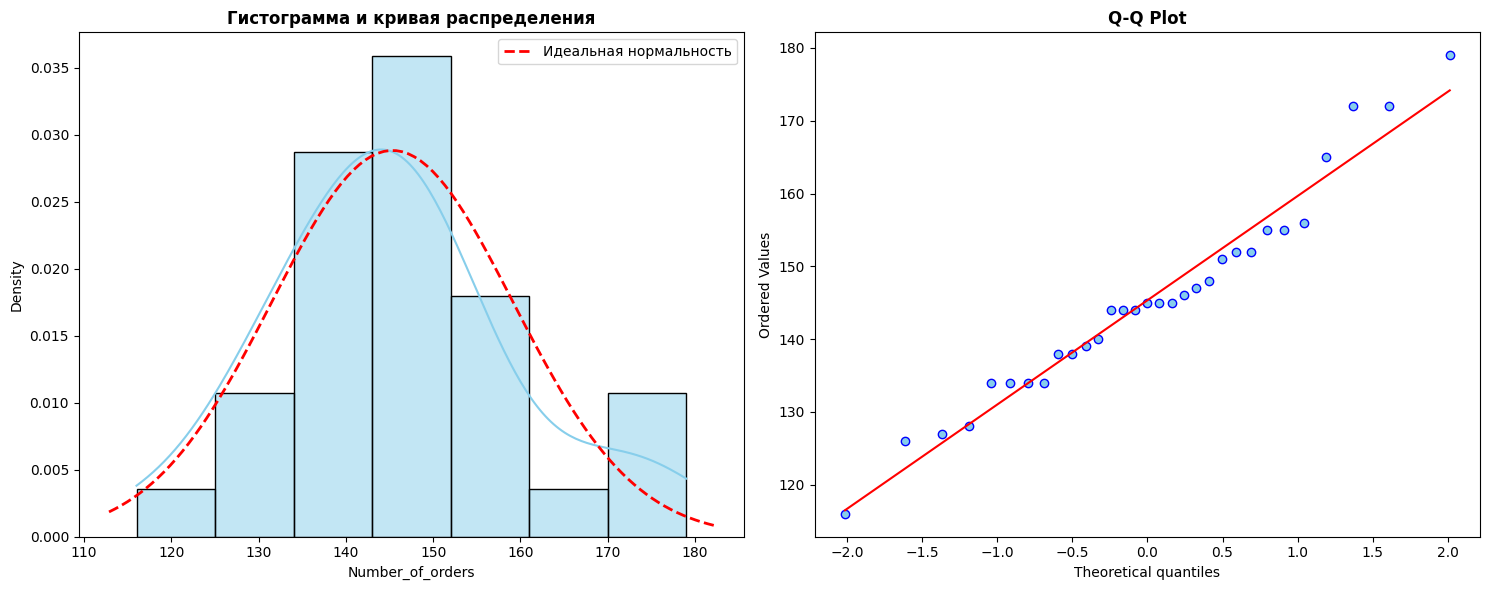

In [54]:
import scipy.stats as stats



fig, axes = plt.subplots(1, 2, figsize=(15, 6))


sns.histplot(daily_average_orders['Number_of_orders'], kde=True, stat="density", ax=axes[0], color='skyblue', edgecolor='black')

mu, std = stats.norm.fit(daily_average_orders['Number_of_orders'])
xmin, xmax = axes[0].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
axes[0].plot(x, p, 'r--', linewidth=2, label='Идеальная нормальность')
axes[0].set_title('Гистограмма и кривая распределения', weight='bold')
axes[0].legend()


stats.probplot(daily_average_orders['Number_of_orders'], dist="norm", plot=axes[1])
axes[1].get_lines()[0].set_markerfacecolor('skyblue')
axes[1].get_lines()[0].set_markeredgecolor('blue')
axes[1].get_lines()[1].set_color('red')
axes[1].set_title('Q-Q Plot', weight='bold')

plt.tight_layout()
plt.show()


In [55]:
day_of_week_totals = analysis_set.groupby('Transaction_Date')['Transaction_ID'].count().reset_index(name='Number_of_orders')
day_of_week_totals['Day_of_week'] = day_of_week_totals['Transaction_Date'].dt.dayofweek
day_of_week_map = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
day_of_week_totals['Day'] = day_of_week_totals['Day_of_week'].map(day_of_week_map)

day_of_week_totals

,Transaction_Date,Number_of_orders,Day_of_week,Day
0,2019-01-01,89,1,Tuesday
1,2019-01-02,115,2,Wednesday
2,2019-01-03,207,3,Thursday
3,2019-01-04,169,4,Friday
4,2019-01-05,189,5,Saturday
...,...,...,...,...
360,2019-12-27,103,4,Friday
361,2019-12-28,80,5,Saturday
362,2019-12-29,89,6,Sunday
363,2019-12-30,61,0,Monday


In [56]:
day_of_week_totals = day_of_week_totals.groupby('Day')['Number_of_orders'].mean().round(0).reset_index()
day_of_week_totals

,Day,Number_of_orders
0,Friday,178.0
1,Monday,86.0
2,Saturday,157.0
3,Sunday,164.0
4,Thursday,173.0
5,Tuesday,87.0
6,Wednesday,171.0


In [57]:
correct_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_of_week_totals['Day'] = pd.Categorical(day_of_week_totals['Day'], categories=correct_order, ordered=True)
day_of_week_totals = day_of_week_totals.sort_values('Day').reset_index(drop=True)
day_of_week_totals


,Day,Number_of_orders
0,Monday,86.0
1,Tuesday,87.0
2,Wednesday,171.0
3,Thursday,173.0
4,Friday,178.0
5,Saturday,157.0
6,Sunday,164.0


(array([  0.,  25.,  50.,  75., 100., 125., 150., 175., 200.]),
 [Text(0, 0.0, '0'),
  Text(0, 25.0, '25'),
  Text(0, 50.0, '50'),
  Text(0, 75.0, '75'),
  Text(0, 100.0, '100'),
  Text(0, 125.0, '125'),
  Text(0, 150.0, '150'),
  Text(0, 175.0, '175'),
  Text(0, 200.0, '200')])

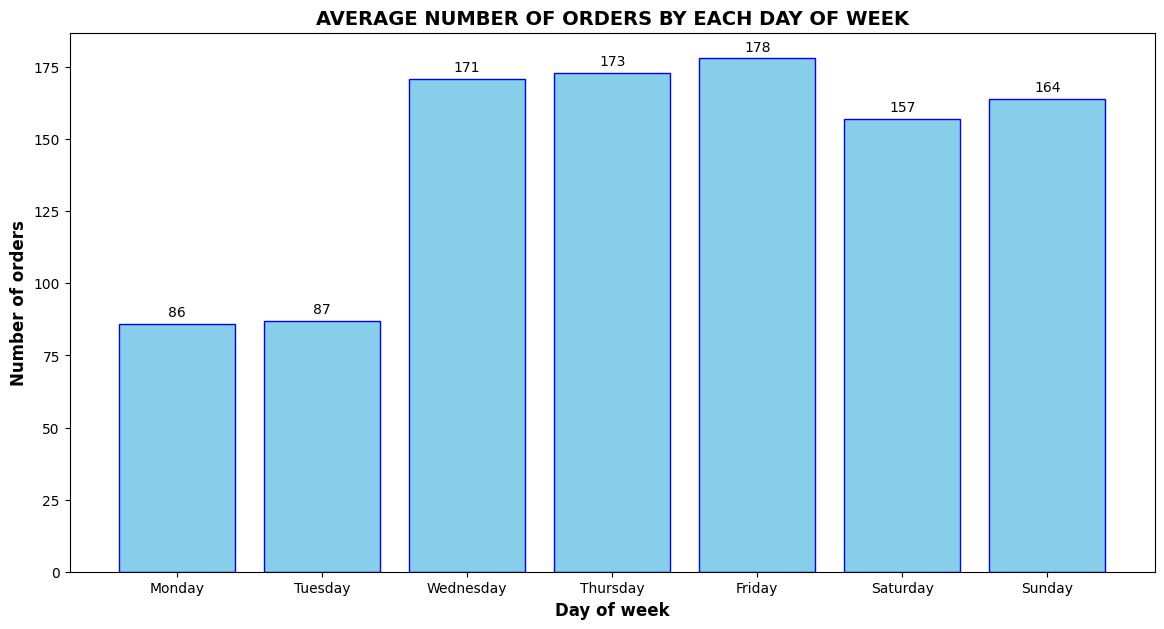

In [58]:
plt.figure(figsize = (14, 7))

bars = plt.bar(
    day_of_week_totals['Day'],
    day_of_week_totals['Number_of_orders'],
    color = 'skyblue',
    edgecolor = 'blue'
)

plt.bar_label(bars, fmt='%.0f', padding=3, fontsize=10)

plt.title('AVERAGE NUMBER OF ORDERS BY EACH DAY OF WEEK', weight = 'bold', fontsize = 14)
plt.ylabel('Number of orders', weight = 'bold', fontsize = 12)
plt.xlabel('Day of week', weight = 'bold', fontsize = 12)
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)

In [59]:
marketing_spend_set['Transaction_Date'] = pd.to_datetime(marketing_spend_set['Date'])
stp1 = analysis_set.groupby('Transaction_Date')['Transaction_ID'].size().round(2).reset_index(name = 'Number_of_orders')
marketing_corr_analysis = pd.merge(marketing_spend_set, stp1, on='Transaction_Date', how = 'left')

marketing_corr_analysis = marketing_corr_analysis.drop('Transaction_Date', axis = 1)
marketing_corr_analysis['Total_Spend'] = marketing_corr_analysis['Offline_Spend'] + marketing_corr_analysis['Online_Spend']

marketing_corr_analysis

,Date,Offline_Spend,Online_Spend,Number_of_orders,Total_Spend
0,1/1/2019,4500,2424.50,89,6924.50
1,1/2/2019,4500,3480.36,115,7980.36
2,1/3/2019,4500,1576.38,207,6076.38
3,1/4/2019,4500,2928.55,169,7428.55
4,1/5/2019,4500,4055.30,189,8555.30
...,...,...,...,...,...
360,12/27/2019,4000,3396.87,103,7396.87
361,12/28/2019,4000,3246.84,80,7246.84
362,12/29/2019,4000,2546.58,89,6546.58
363,12/30/2019,4000,674.31,61,4674.31


In [60]:
x = marketing_corr_analysis['Number_of_orders']
y = marketing_corr_analysis['Total_Spend']

res_x = stats.normaltest(x)
res_y = stats.normaltest(y)

print(f"Numer of orders: p-value = {res_x.pvalue:.4f}")
print(f"Marketing spends: p-value = {res_y.pvalue:.4f}")

if res_x.pvalue > 0.05 and res_y.pvalue > 0.05:
  print('Pearson correlation')
  correlation_ratio = stats.pearsonr(x, y).statistic
  print(f"Correlation ratio = {correlation_ratio:.4f}")
else:
  print('Spearman correlation')
  correlation_ratio = stats.spearmanr(x, y).statistic
  print(f"Correlation ratio = {correlation_ratio:.4f}")



Numer of orders: p-value = 0.0205
Marketing spends: p-value = 0.7555
Spearman correlation
Correlation ratio = -0.0697


In [61]:
import datetime as dt

snapshot_date = analysis_set['Transaction_Date'].max() + dt.timedelta(days=1)

rfm = analysis_set.groupby('CustomerID').agg({
    'Transaction_Date': lambda x: (snapshot_date - x.max()).days,
    'Transaction_ID': 'nunique',
    'Invoice_amount': 'sum'
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

rfm

,CustomerID,Recency,Frequency,Monetary
0,12346,108,1,-128.30700
1,12347,60,31,10475.44164
2,12348,74,8,961.47050
3,12350,18,11,964.04872
4,12356,108,13,506.93554
...,...,...,...,...
1463,18259,271,3,235.57310
1464,18260,88,19,1310.58624
1465,18269,195,2,37.47270
1466,18277,70,1,262.80000


In [62]:
rfm['R'] = pd.qcut(rfm['Recency'], q=4, labels=[4, 3, 2, 1])
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4])
rfm['M'] = pd.qcut(rfm['Monetary'], q=4, labels=[1, 2, 3, 4])

rfm['RFM_Score'] = rfm['R'].astype(int) + rfm['F'].astype(int) + rfm['M'].astype(int)

def assign_segment(df):
    score = df['RFM_Score']
    if score >= 10:
        return 'Premium'
    elif score >= 8:
        return 'Gold'
    elif score >= 5:
        return 'Silver'
    else:
        return 'Standard'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

print(rfm['Segment'].value_counts())

Segment
Silver      501
Premium     408
Gold        316
Standard    243
Name: count, dtype: int64


In [63]:
rfm_analysis = rfm.groupby('Segment')['CustomerID'].nunique().reset_index(name='Number_of_customers')

correct_order = ['Premium', 'Gold', 'Silver', 'Standard']
rfm_analysis['Segment'] = pd.Categorical(rfm_analysis['Segment'], categories=correct_order, ordered=True)
rfm_analysis = rfm_analysis.sort_values('Segment').reset_index(drop=True)

rfm_analysis

,Segment,Number_of_customers
0,Premium,408
1,Gold,316
2,Silver,501
3,Standard,243


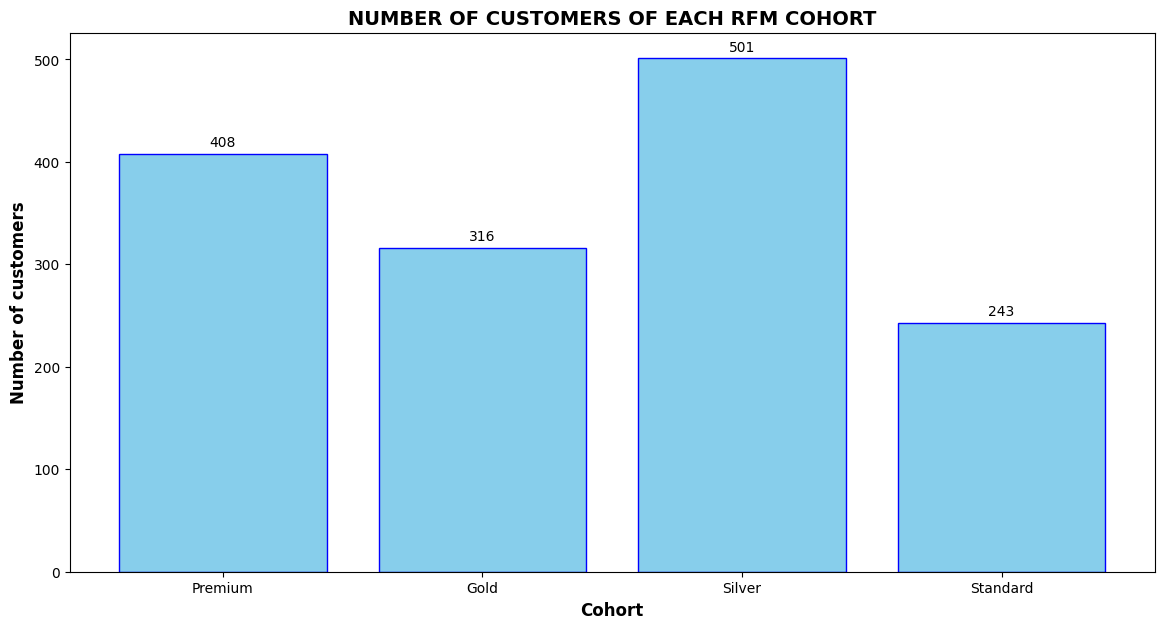

In [64]:
plt.figure(figsize = (14, 7))

bars = plt.bar(
    rfm_analysis['Segment'],
    rfm_analysis['Number_of_customers'],
    color = 'skyblue',
    edgecolor = 'blue'
)

plt.bar_label(bars, fmt="%.0f", padding=3, fontsize = 10)

plt.title('NUMBER OF CUSTOMERS OF EACH RFM COHORT', weight = 'bold', fontsize = 14)
plt.ylabel('Number of customers', weight = 'bold', fontsize = 12)
plt.xlabel('Cohort', weight = 'bold', fontsize = 12)
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)

plt.show()

In [65]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

rfm_log = np.log1p(rfm[['Recency', 'Frequency', 'Monetary']])
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled = rfm_scaled[~np.isnan(rfm_scaled).any(axis=1)]

/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


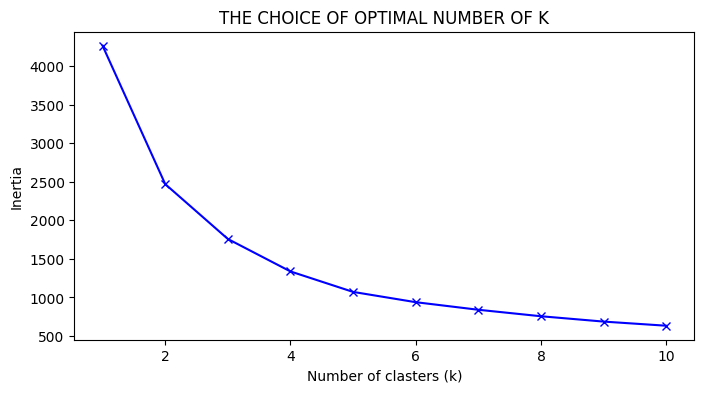

In [66]:
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Number of clasters (k)')
plt.ylabel('Inertia')
plt.title('THE CHOICE OF OPTIMAL NUMBER OF K')
plt.show()

In [67]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans



rfm_clean = rfm[(rfm['Recency'] >= 0) & (rfm['Frequency'] > 0) & (rfm['Monetary'] > 0)].copy()


rfm_log = np.log1p(rfm_clean[['Recency', 'Frequency', 'Monetary']])
scaler = StandardScaler()
rfm_scaled_clean = scaler.fit_transform(rfm_log)


kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)


rfm_clean['K_Cluster'] = kmeans.fit_predict(rfm_scaled_clean)


cluster_profiles = rfm_clean.groupby('K_Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CustomerID': 'count'
}).rename(columns={'CustomerID': 'Count'}).round(1)


cluster_profiles


,Recency,Frequency,Monetary,Count
K_Cluster,,,,
0,140.2,38.2,4998.7,438
1,182.9,2.0,88.7,192
2,23.0,19.2,2636.6,273
3,194.5,8.0,879.4,531


In [68]:
cluster_mapping = {
    2: 'Premium',
    0: 'Gold',
    3: 'Silver',
    1: 'Standard'
}

rfm_clean['K_Cluster_Name'] = rfm_clean['K_Cluster'].map(cluster_mapping)

rfm_clean[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'K_Cluster_Name']]

,CustomerID,Recency,Frequency,Monetary,K_Cluster_Name
1,12347,60,31,10475.44164,Gold
2,12348,74,8,961.47050,Silver
3,12350,18,11,964.04872,Premium
4,12356,108,13,506.93554,Silver
5,12359,131,3,420.34520,Silver
...,...,...,...,...,...
1463,18259,271,3,235.57310,Silver
1464,18260,88,19,1310.58624,Gold
1465,18269,195,2,37.47270,Standard
1466,18277,70,1,262.80000,Standard


In [69]:
klaster_analysis = rfm_clean.groupby('K_Cluster_Name')['CustomerID'].nunique().reset_index(name = 'Number of customers (K-method)')
klaster_analysis

,K_Cluster_Name,Number of customers (K-method)
0,Gold,438
1,Premium,273
2,Silver,531
3,Standard,192


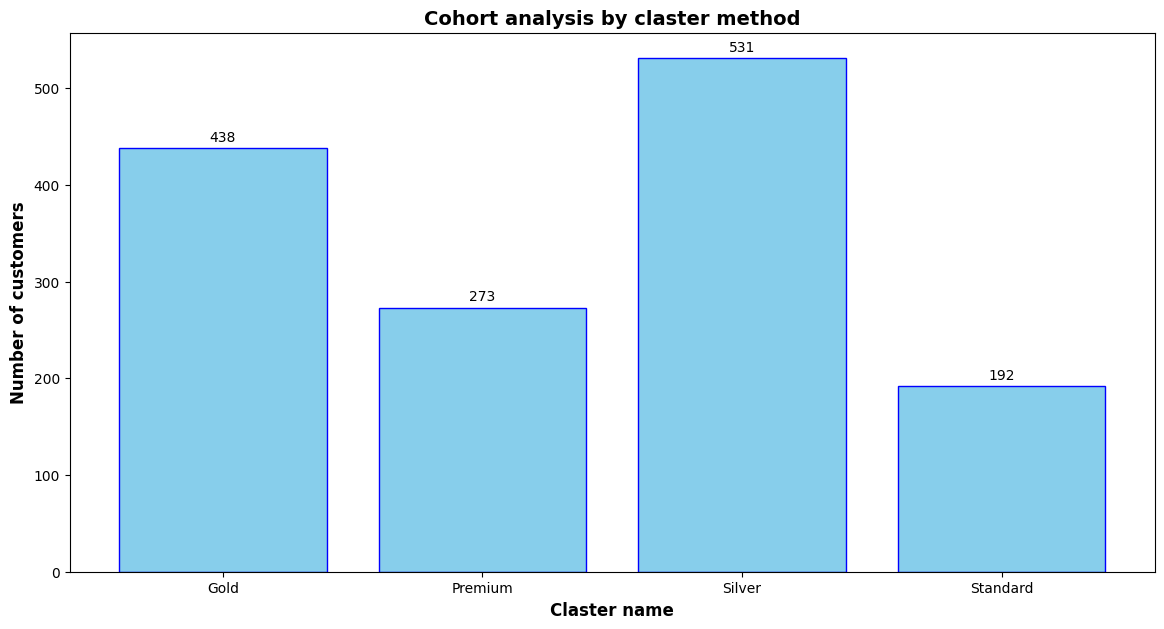

In [70]:
plt.figure(figsize=(14, 7))

bars = plt.bar(
    klaster_analysis['K_Cluster_Name'],
    klaster_analysis['Number of customers (K-method)'],
    color = 'skyblue',
    edgecolor = 'blue'
)

plt.bar_label(bars, padding = 3, fmt = '%.0f', fontsize = 10)

plt.title('Cohort analysis by claster method', weight = 'bold', fontsize = 14)
plt.xlabel('Claster name', weight = 'bold', fontsize = 12)
plt.ylabel('Number of customers', weight = 'bold', fontsize = 12)
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)

plt.show()

In [71]:
comparison_matrix = pd.crosstab(
    rfm_clean['Segment'],
    rfm_clean['K_Cluster_Name'],
    margins=True,
    margins_name="TOTAL"
)


comparison_matrix


K_Cluster_Name,Gold,Premium,Silver,Standard,TOTAL
Segment,,,,,
Gold,164,78,74,0,316
Premium,249,159,0,0,408
Silver,25,36,367,63,491
Standard,0,0,90,129,219
TOTAL,438,273,531,192,1434


In [72]:
rank_map = {'Standard': 1, 'Silver': 2, 'Gold': 3, 'Premium': 4}

rfm_clean['Rank_Rules'] = rfm_clean['Segment'].map(rank_map)
rfm_clean['Rank_KMeans'] = rfm_clean['K_Cluster_Name'].map(rank_map)

rfm_clean['Stabilized_Score'] = (rfm_clean['Rank_Rules'] + rfm_clean['Rank_KMeans']) / 2

def get_stable_cohort(score):
    if score >= 3.5:  return 'Stable_Premium'
    elif score >= 2.5: return 'Stable_Gold'
    elif score >= 1.5: return 'Stable_Silver'
    else:              return 'Stable_Standard'

rfm_clean['Stable_Cohort'] = rfm_clean['Stabilized_Score'].apply(get_stable_cohort)

stable_cohort = rfm_clean.groupby('Stable_Cohort').agg(
    Number_of_customers = ('CustomerID', 'nunique'),
    Average_monetory = ('Monetary', 'mean'),
    Averarage_recency = ('Recency', 'mean')
).reset_index()

stable_cohort

,Stable_Cohort,Number_of_customers,Average_monetory,Averarage_recency
0,Stable_Gold,299,2370.402128,167.438127
1,Stable_Premium,486,4762.577527,56.802469
2,Stable_Silver,520,691.319931,190.107692
3,Stable_Standard,129,80.464676,229.124031


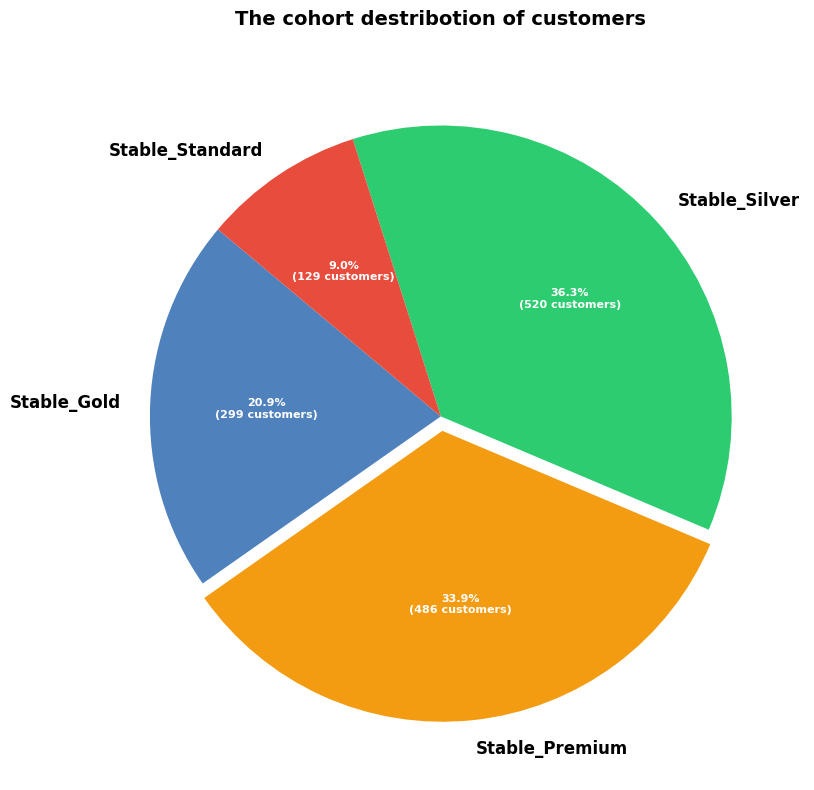

In [73]:
plt.figure(figsize=(10, 8))


colors = ['#4f81bd', '#f39c12', '#2ecc71', '#e74c3c']


explode = (0, 0.05, 0, 0)

def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f"{pct:.1f}%\n({val} customers)"
    return my_autopct

wedges, texts, autotexts = plt.pie(
    stable_cohort['Number_of_customers'],
    labels=stable_cohort['Stable_Cohort'],
    autopct=make_autopct(stable_cohort['Number_of_customers']),
    startangle=140,
    colors=colors,
    explode=explode,
    textprops=dict(color="black", fontsize=12, weight='bold')
)


for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_weight('bold')
    autotext.set_fontsize(8)

plt.title('The cohort destribotion of customers', weight='bold', fontsize=14, pad=20)
plt.tight_layout()
plt.show()


In [74]:
stb_cohort = rfm_clean.reset_index()[['CustomerID', 'Stable_Cohort']]
analysis_set = pd.merge(analysis_set, stb_cohort, on = 'CustomerID', how = 'left')
analysis_set.head()

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,...,Discount_pct,Disc_Status,Revenue,EBIT,GST_value,Invoice_amount,Cohort_Month,Transaction_Month,User_Type,Stable_Cohort
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,...,10.0,1,153.71,131.839,13.1839,118.6551,2019-01,2019-01,New,Stable_Gold
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,...,10.0,1,153.71,131.839,13.1839,118.6551,2019-01,2019-01,New,Stable_Gold
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,...,10.0,1,2.05,-4.655,0.0000,-4.6550,2019-01,2019-01,New,Stable_Gold
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used,...,10.0,0,87.65,81.150,14.6070,66.5430,2019-01,2019-01,New,Stable_Gold
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used,...,10.0,1,16.50,8.350,1.5030,6.8470,2019-01,2019-01,New,Stable_Gold


In [75]:
cohort_category = pd.crosstab(
    analysis_set['Product_Category'],
    analysis_set['Stable_Cohort'],
    margins = True,
    margins_name = 'Total'
)

cohort_category

Stable_Cohort,Stable_Gold,Stable_Premium,Stable_Silver,Stable_Standard,Total
Product_Category,,,,,
Accessories,28,186,19,0,233
Android,11,24,8,0,43
Apparel,3993,11061,2784,230,18068
Backpacks,26,53,9,1,89
Bags,440,1138,270,28,1876
Bottles,75,150,40,2,267
Drinkware,869,2033,510,45,3457
Fun,43,92,22,2,159
Gift Cards,31,112,16,0,159


In [76]:
cohort_category = pd.merge(cohort_category, product_category_analysis[['Product_Category', 'Net_profit_margin']], on = 'Product_Category', how = 'left')
cohort_category = cohort_category.iloc[:20]
cohort_category

,Product_Category,Stable_Gold,Stable_Premium,Stable_Silver,Stable_Standard,Total,Net_profit_margin
0,Accessories,28,186,19,0,233,0.47
1,Android,11,24,8,0,43,0.39
2,Apparel,3993,11061,2784,230,18068,0.51
3,Backpacks,26,53,9,1,89,0.78
4,Bags,440,1138,270,28,1876,0.63
5,Bottles,75,150,40,2,267,0.38
6,Drinkware,869,2033,510,45,3457,0.56
7,Fun,43,92,22,2,159,0.55
8,Gift Cards,31,112,16,0,159,0.90
9,Google,33,55,14,0,102,0.63


In [77]:
cohort_category['Gold*'] = cohort_category['Stable_Gold'] * cohort_category['Net_profit_margin']
cohort_category['Premium*'] = cohort_category['Stable_Premium'] * cohort_category['Net_profit_margin']
cohort_category['Silver*'] = cohort_category['Stable_Silver'] * cohort_category['Net_profit_margin']
cohort_category['Standard*'] = cohort_category['Stable_Standard'] * cohort_category['Net_profit_margin']
cohort_category

,Product_Category,Stable_Gold,Stable_Premium,Stable_Silver,Stable_Standard,Total,Net_profit_margin,Gold*,Premium*,Silver*,Standard*
0,Accessories,28,186,19,0,233,0.47,13.16,87.42,8.93,0.00
1,Android,11,24,8,0,43,0.39,4.29,9.36,3.12,0.00
2,Apparel,3993,11061,2784,230,18068,0.51,2036.43,5641.11,1419.84,117.30
3,Backpacks,26,53,9,1,89,0.78,20.28,41.34,7.02,0.78
4,Bags,440,1138,270,28,1876,0.63,277.20,716.94,170.10,17.64
5,Bottles,75,150,40,2,267,0.38,28.50,57.00,15.20,0.76
6,Drinkware,869,2033,510,45,3457,0.56,486.64,1138.48,285.60,25.20
7,Fun,43,92,22,2,159,0.55,23.65,50.60,12.10,1.10
8,Gift Cards,31,112,16,0,159,0.90,27.90,100.80,14.40,0.00
9,Google,33,55,14,0,102,0.63,20.79,34.65,8.82,0.00


In [78]:
Stable_Gold_margin = cohort_category['Gold*'].sum() / cohort_category['Stable_Gold'].sum()
Stable_Premium_margin = cohort_category['Premium*'].sum() / cohort_category['Stable_Premium'].sum()
Stable_Silver_margin = cohort_category['Silver*'].sum() / cohort_category['Stable_Silver'].sum()
Stable_Standard_margin = cohort_category['Standard*'].sum() / cohort_category['Stable_Standard'].sum()

stable_cohort['Average_margin'] = [Stable_Gold_margin, Stable_Premium_margin, Stable_Silver_margin, Stable_Standard_margin]

max_recency = rfm_clean['Recency'].max()

stable_cohort['Churn_rate'] = stable_cohort['Averarage_recency'] / max_recency
stable_cohort['Churn_rate'] = stable_cohort['Churn_rate'].clip(0.05, 0.95)

stable_cohort['Life_Time_Value'] = ((stable_cohort['Average_monetory'] * stable_cohort['Average_margin']) / stable_cohort['Churn_rate']).round(2)

stable_cohort[['Stable_Cohort', 'Life_Time_Value']]

,Stable_Cohort,Life_Time_Value
0,Stable_Gold,3041.70
1,Stable_Premium,18462.88
2,Stable_Silver,762.90
3,Stable_Standard,69.39


In [79]:
stable_cohort = stable_cohort.sort_values(by='Life_Time_Value', ascending=False)
stable_cohort

,Stable_Cohort,Number_of_customers,Average_monetory,Averarage_recency,Average_margin,Churn_rate,Life_Time_Value
1,Stable_Premium,486,4762.577527,56.802469,0.604955,0.156051,18462.88
0,Stable_Gold,299,2370.402128,167.438127,0.590266,0.459995,3041.70
2,Stable_Silver,520,691.319931,190.107692,0.576349,0.522274,762.90
3,Stable_Standard,129,80.464676,229.124031,0.542801,0.629462,69.39


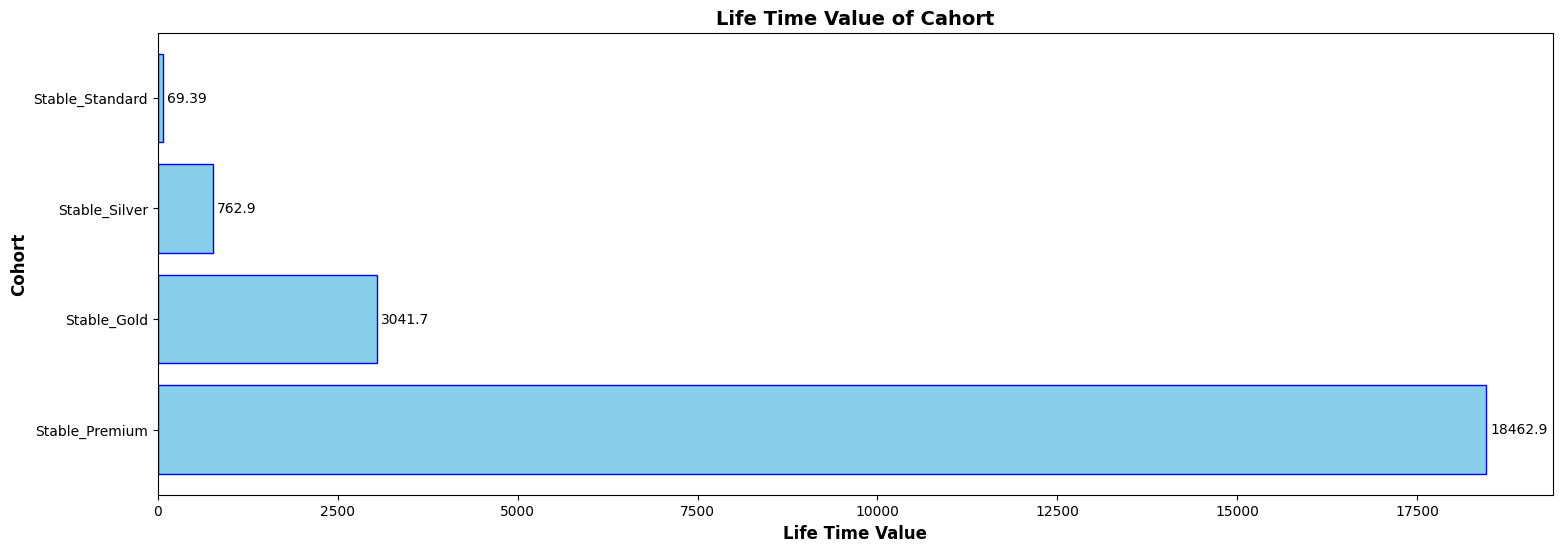

In [80]:
plt.figure(figsize = (18, 6))

bars = plt.barh(
    stable_cohort['Stable_Cohort'],
    stable_cohort['Life_Time_Value'],
    color = 'skyblue',
    edgecolor = 'blue'
)

plt.bar_label(bars, padding = 3, fontsize = 10, fmt = '%g')

plt.title('Life Time Value of Cahort', weight = 'bold', fontsize = 14)
plt.ylabel('Cohort', weight = 'bold', fontsize = 12)
plt.xlabel('Life Time Value', weight = 'bold', fontsize = 12)

plt.show()

In [81]:
discount_corr_analysis = discount_corr_analysis.rename(columns={'Customer_ID': 'CustomerID'})
discount_corr_analysis

,CustomerID,Number_of_orders,Percent_of_discount_usage,Total_profit,Average_profit,Discount_Frequency
0,12346,2,1.00,-128.31,-64.15,Always
1,12347,60,0.33,10475.44,174.59,Sometimes
2,12348,23,0.48,961.47,41.80,Sometimes
3,12350,17,0.35,964.05,56.71,Sometimes
4,12356,36,0.31,506.94,14.08,Sometimes
...,...,...,...,...,...,...
1463,18259,7,0.43,235.57,33.65,Sometimes
1464,18260,40,0.40,1310.59,32.76,Sometimes
1465,18269,8,0.38,37.47,4.68,Sometimes
1466,18277,1,0.00,262.80,262.80,Never


In [82]:
cohort_discount_raw = pd.merge(rfm_clean, discount_corr_analysis[['CustomerID', 'Discount_Frequency']], on='CustomerID', how='left')

cohort_discount_counts = pd.crosstab(
    cohort_discount_raw['Stable_Cohort'],
    cohort_discount_raw['Discount_Frequency']
)

cohort_discount_pct = pd.crosstab(
    cohort_discount_raw['Stable_Cohort'],
    cohort_discount_raw['Discount_Frequency'],
    normalize='index'
) * 100

cohort_discount_pct = cohort_discount_pct.round(1)

cohort_discount_pct

Discount_Frequency,Never,Sometimes,Usually,Always
Stable_Cohort,,,,
Stable_Gold,2.7,93.6,3.7,0.0
Stable_Premium,0.0,98.1,1.9,0.0
Stable_Silver,5.6,82.1,10.6,1.7
Stable_Standard,34.1,45.7,9.3,10.9


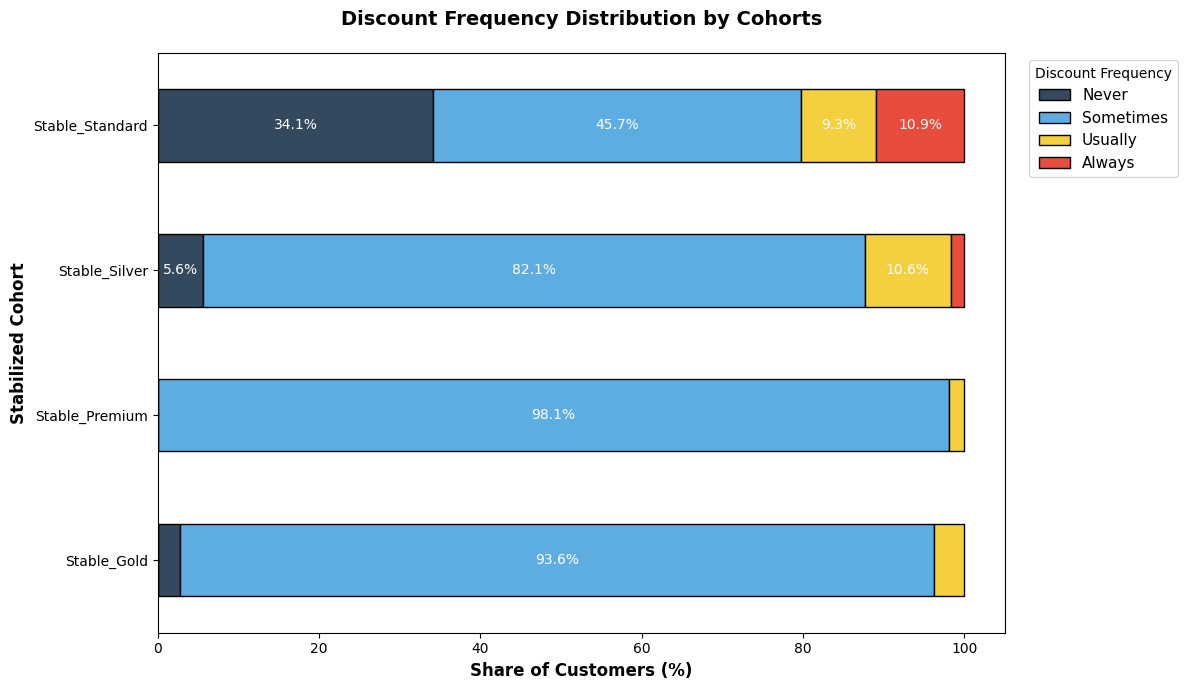

In [83]:
colors = ['#34495e', '#5dade2', '#f4d03f', '#e74c3c']

ax = cohort_discount_pct.plot(
    kind='barh',
    stacked=True,
    figsize=(12, 7),
    color=colors,
    edgecolor='black'
)

plt.title('Discount Frequency Distribution by Cohorts', weight='bold', fontsize=14, pad=20)
plt.xlabel('Share of Customers (%)', weight='bold', fontsize=12)
plt.ylabel('Stabilized Cohort', weight='bold', fontsize=12)

for c in ax.containers:
    labels = [f'{v:.1f}%' if v > 5.0 else '' for v in c.datavalues]
    ax.bar_label(c, labels=labels, label_type='center', color='white', fontsize=10)

plt.legend(title='Discount Frequency', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()


In [84]:
!pip install mlxtend
import warnings

warnings.filterwarnings('ignore')

In [85]:
from mlxtend.frequent_patterns import apriori, association_rules


basket = (analysis_set.groupby(['Transaction_ID', 'Product_Description'])['Quantity']
          .sum()
          .unstack()
          .reset_index()
          .fillna(0)
          .set_index('Transaction_ID'))


def encode_units(x):
    if x <= 0:
        return 0
    return 1

basket_sets = basket.applymap(encode_units)


warnings.filterwarnings('ignore')

In [86]:

warnings.filterwarnings('ignore')


frequent_itemsets = apriori(basket_sets, min_support=0.005, use_colnames=True)


rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)


rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)
result_rules = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]


result_rules.head(15)


,antecedents,consequents,support,confidence,lift
0,(YouTube Custom Decals),(Google Laptop and Cell Phone Stickers),0.005347,0.319809,9.943840
1,(Google Laptop and Cell Phone Stickers),(YouTube Custom Decals),0.005347,0.166253,9.943840
2,(Nest Cam Outdoor Security Camera - USA),(Nest Cam Indoor Security Camera - USA),0.027653,0.208233,1.615644
3,(Nest Cam Indoor Security Camera - USA),(Nest Cam Outdoor Security Camera - USA),0.027653,0.214551,1.615644
4,(Nest Protect Smoke + CO White Wired Alarm-USA),(Nest Learning Thermostat 3rd Gen-USA - Stainl...,0.007222,0.169953,1.213100
5,(Nest Learning Thermostat 3rd Gen-USA - Stainl...,(Nest Protect Smoke + CO White Wired Alarm-USA),0.007222,0.051552,1.213100
6,(Nest Learning Thermostat 3rd Gen-USA - Stainl...,(Nest Protect Smoke + CO White Battery Alarm-USA),0.009018,0.064369,1.185272
7,(Nest Protect Smoke + CO White Battery Alarm-USA),(Nest Learning Thermostat 3rd Gen-USA - Stainl...,0.009018,0.166054,1.185272
8,(Nest Protect Smoke + CO White Battery Alarm-USA),(Nest Cam Outdoor Security Camera - USA),0.007661,0.141073,1.062327
9,(Nest Cam Outdoor Security Camera - USA),(Nest Protect Smoke + CO White Battery Alarm-USA),0.007661,0.057692,1.062327


In [87]:
result_rules['antecedents'].value_counts()

,count
antecedents,
(Nest Cam Outdoor Security Camera - USA),2
(Nest Learning Thermostat 3rd Gen-USA - Stainless Steel),2
(Nest Protect Smoke + CO White Battery Alarm-USA),2
(Google Laptop and Cell Phone Stickers),1
(YouTube Custom Decals),1
(Nest Protect Smoke + CO White Wired Alarm-USA),1
(Nest Cam Indoor Security Camera - USA),1


<Figure size 2000x1000 with 0 Axes>

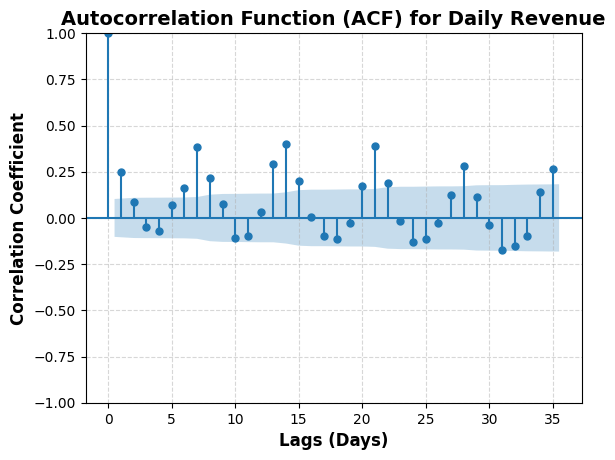

In [88]:
import statsmodels as stats
from statsmodels.graphics.tsaplots import plot_acf

daily_revenue = analysis_set.groupby('Transaction_Date')['Revenue'].sum().reset_index()
daily_revenue

plt.figure(figsize=(20, 10))


plot_acf(daily_revenue['Revenue'], lags=35, alpha=0.05)

plt.title('Autocorrelation Function (ACF) for Daily Revenue', weight='bold', fontsize=14)
plt.xlabel('Lags (Days)', weight='bold', fontsize=12)
plt.ylabel('Correlation Coefficient', weight='bold', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [89]:
daily_revenue['Transaction_Date'] = pd.to_datetime(daily_revenue['Transaction_Date'])
daily_revenue = daily_revenue.sort_values('Transaction_Date').set_index('Transaction_Date')
daily_revenue = daily_revenue.asfreq('D')
daily_revenue

,Revenue
Transaction_Date,
2019-01-01,7380.49
2019-01-02,13438.47
2019-01-03,23834.21
2019-01-04,16603.41
2019-01-05,17373.19
...,...
2019-12-27,13661.59
2019-12-28,10994.42
2019-12-29,12011.27


Метрики качества на тестовой выборке:
                    MAE  MAPE %
Seasonal_Naive  8106.19   53.89
ETS             4387.13   34.56


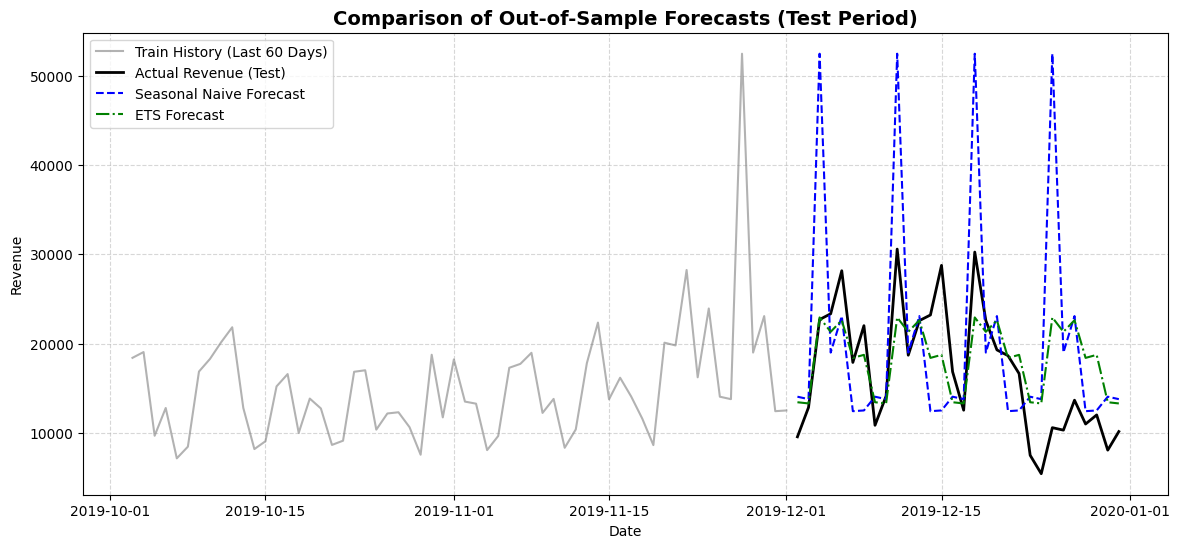

In [90]:
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error


test_size = 30
train = daily_revenue['Revenue'].iloc[:-test_size]
test = daily_revenue['Revenue'].iloc[-test_size:]


forecasts = pd.DataFrame(index=test.index)
forecasts['Actual'] = test

s_naive_pred = []
for i in range(test_size):
    history = pd.concat([train, pd.Series(s_naive_pred, index=test.index[:len(s_naive_pred)])])
    s_naive_pred.append(history.iloc[-7])

forecasts['Seasonal_Naive'] = s_naive_pred
train_float = train.astype(float)

ets_model = ETSModel(train_float, error='add', trend=None, seasonal='add', seasonal_periods=7)
ets_fitted = ets_model.fit(disp=False)

forecasts['ETS'] = ets_fitted.forecast(steps=test_size)

metrics = {}
for method in ['Seasonal_Naive', 'ETS']:
    mae = mean_absolute_error(forecasts['Actual'], forecasts[method])
    mape = mean_absolute_percentage_error(forecasts['Actual'], forecasts[method]) * 100
    metrics[method] = {'MAE': round(mae, 2), 'MAPE %': round(mape, 2)}

print("Метрики качества на тестовой выборке:")
print(pd.DataFrame(metrics).T)

plt.figure(figsize=(14, 6))
plt.plot(train.iloc[-60:], label='Train History (Last 60 Days)', color='gray', alpha=0.6)
plt.plot(forecasts['Actual'], label='Actual Revenue (Test)', color='black', linewidth=2)
plt.plot(forecasts['Seasonal_Naive'], label='Seasonal Naive Forecast', linestyle='--', color='blue')
plt.plot(forecasts['ETS'], label='ETS Forecast', linestyle='-.', color='green')

plt.title('Comparison of Out-of-Sample Forecasts (Test Period)', weight='bold', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


Обновленные метрики качества на тестовой выборке:
                    MAE  MAPE %
Seasonal_Naive  8106.19   53.89
ETS             4387.13   34.56
AR              5873.36   34.86
SARIMA          4241.27   28.95


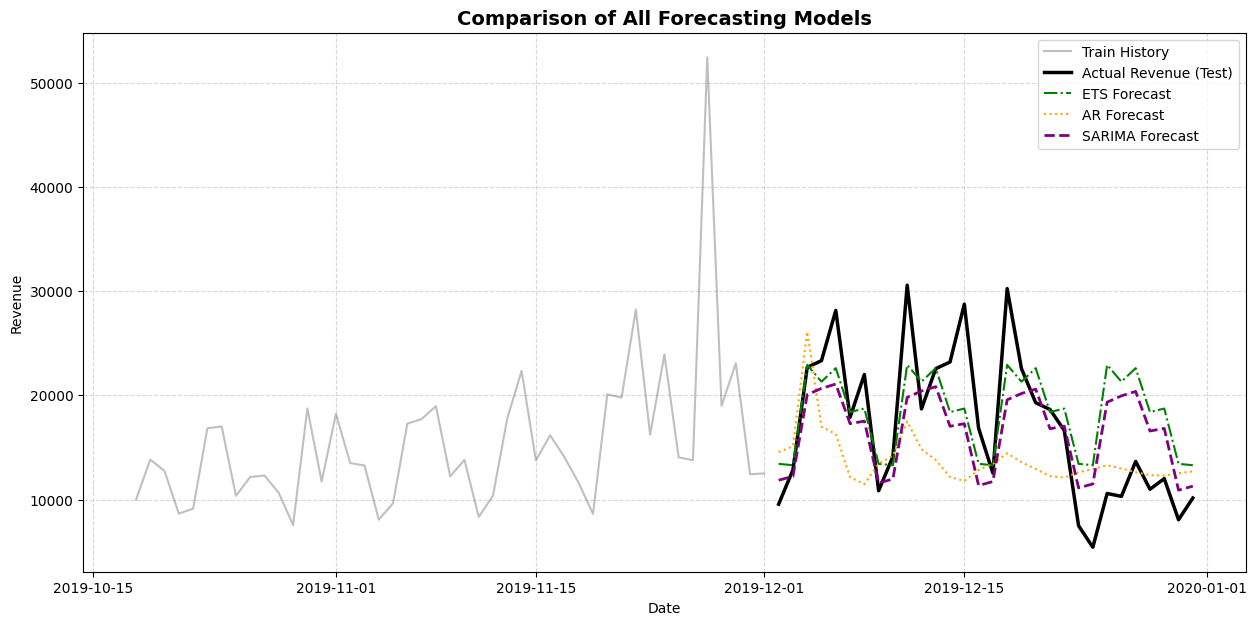

In [91]:
import warnings
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.statespace.sarimax import SARIMAX


warnings.filterwarnings('ignore')


train_float = train.astype(float)


ar_model = AutoReg(train_float, lags=7)
ar_fitted = ar_model.fit()
forecasts['AR'] = ar_fitted.predict(start=len(train), end=len(train) + test_size - 1, dynamic=True).values


sarima_model = SARIMAX(train_float, order=(1, 0, 1), seasonal_order=(1, 0, 1, 7))
sarima_fitted = sarima_model.fit(disp=False)


forecasts['SARIMA'] = sarima_fitted.forecast(steps=test_size)


all_metrics = {}
for method in ['Seasonal_Naive', 'ETS', 'AR', 'SARIMA']:
    mae = mean_absolute_error(forecasts['Actual'], forecasts[method])
    mape = mean_absolute_percentage_error(forecasts['Actual'], forecasts[method]) * 100
    all_metrics[method] = {'MAE': round(mae, 2), 'MAPE %': round(mape, 2)}

print("\nОбновленные метрики качества на тестовой выборке:")
print(pd.DataFrame(all_metrics).T)


plt.figure(figsize=(15, 7))
plt.plot(train.iloc[-45:], label='Train History', color='gray', alpha=0.5)
plt.plot(forecasts['Actual'], label='Actual Revenue (Test)', color='black', linewidth=2.5)
plt.plot(forecasts['ETS'], label='ETS Forecast', linestyle='-.', color='green')
plt.plot(forecasts['AR'], label='AR Forecast', linestyle=':', color='orange')
plt.plot(forecasts['SARIMA'], label='SARIMA Forecast', linestyle='--', color='purple', linewidth=2)

plt.title('Comparison of All Forecasting Models', weight='bold', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


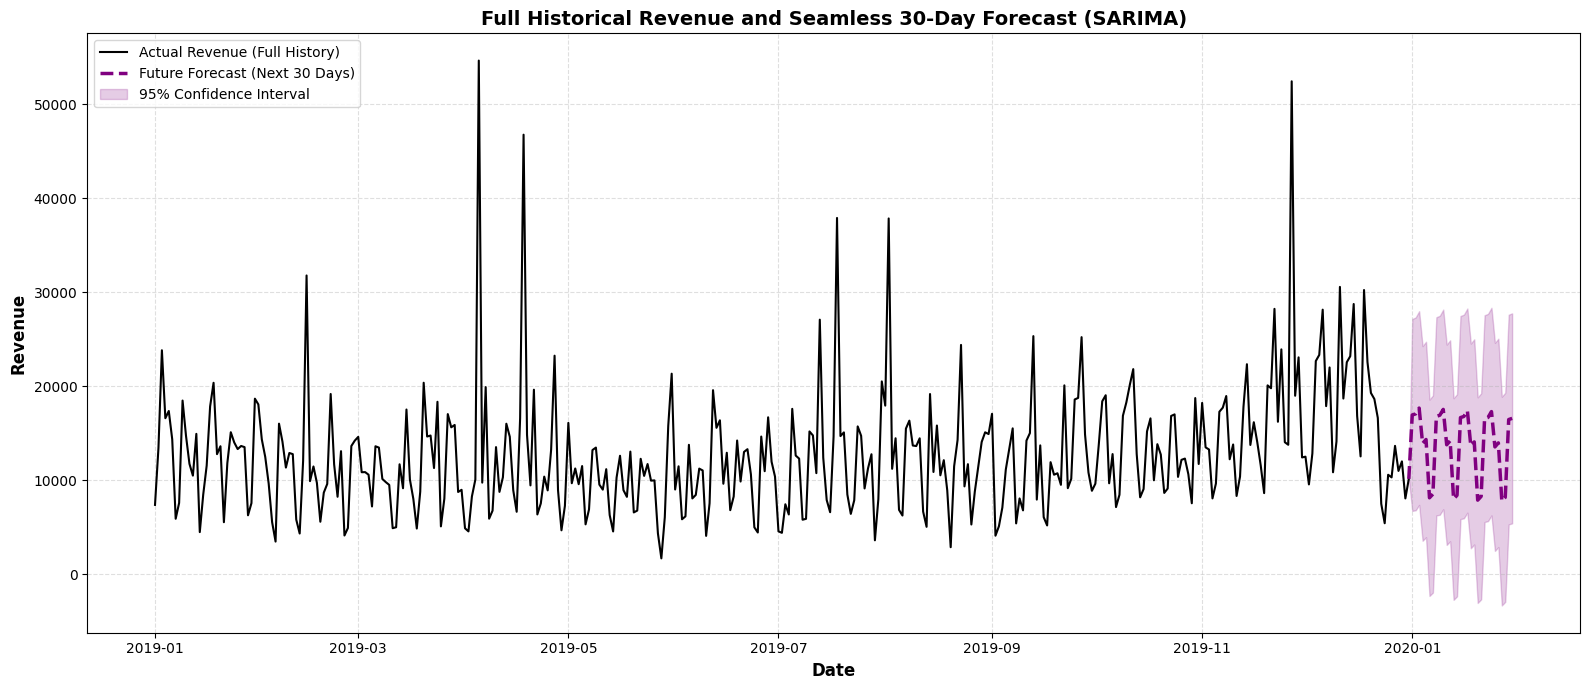

In [94]:
full_data = daily_revenue['Revenue'].astype(float)

final_model = SARIMAX(full_data, order=(1, 0, 1), seasonal_order=(1, 0, 1, 7))
final_fitted = final_model.fit(disp=False)

forecast_steps = 30
forecast_res = final_fitted.get_forecast(steps=forecast_steps)

future_forecast = forecast_res.predicted_mean
ci_95 = forecast_res.conf_int(alpha=0.05)

last_actual_date = full_data.index[-1]
last_actual_value = full_data.iloc[-1]

connected_forecast = pd.concat([pd.Series([last_actual_value], index=[last_actual_date]), future_forecast])
connected_ci_95 = pd.concat([pd.DataFrame([[last_actual_value, last_actual_value]], index=[last_actual_date], columns=ci_95.columns), ci_95])


plt.figure(figsize=(16, 7))

plt.plot(full_data, label='Actual Revenue (Full History)', color='black', linewidth=1.5)

plt.plot(connected_forecast, label='Future Forecast (Next 30 Days)', color='purple', linewidth=2.5, linestyle='--')


plt.fill_between(connected_ci_95.index, connected_ci_95.iloc[:, 0], connected_ci_95.iloc[:, 1],
                 color='purple', alpha=0.20, label='95% Confidence Interval')

plt.title('Full Historical Revenue and Seamless 30-Day Forecast (SARIMA)', weight='bold', fontsize=14)
plt.xlabel('Date', weight='bold', fontsize=12)
plt.ylabel('Revenue', weight='bold', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


In [96]:
customer_timeline = analysis_set.groupby('CustomerID').agg({
    'Transaction_Date': ['min', 'max'],
    'Transaction_ID': 'nunique'
})

customer_timeline.columns = ['First_Purchase', 'Last_Purchase', 'Total_Transactions']
customer_timeline = customer_timeline.reset_index()

repeat_cust = customer_timeline[customer_timeline['Total_Transactions'] > 1].copy()

repeat_cust['Lifespan_Days'] = (repeat_cust['Last_Purchase'] - repeat_cust['First_Purchase']).dt.days
repeat_cust['Avg_Days_Per_Transaction'] = repeat_cust['Lifespan_Days'] / (repeat_cust['Total_Transactions'] - 1)

def get_target_class(days):
    if days <= 30:   return '0-30 days'
    elif days <= 60: return '30-60 days'
    elif days <= 90: return '60-90 days'
    else:            return '90+ days'

repeat_cust['Target_Class'] = repeat_cust['Avg_Days_Per_Transaction'].apply(get_target_class)

print(repeat_cust['Target_Class'].value_counts())


Target_Class
0-30 days     1291
30-60 days      33
60-90 days      11
90+ days         8
Name: count, dtype: int64


In [99]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score


ml_dataset = pd.merge(
    repeat_cust[['CustomerID', 'Target_Class']],
    rfm_clean[['CustomerID', 'Recency', 'Frequency', 'Monetary']],
    on='CustomerID',
    how='inner'
)


X = ml_dataset[['Recency', 'Frequency', 'Monetary']]
Y = ml_dataset['Target_Class']


X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)


clf_model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=6)
clf_model.fit(X_train, Y_train)


Y_pred = clf_model.predict(X_test)


print(f"Accuracy: {accuracy_score(Y_test, Y_pred):.2f}\n")
print("Classification Report:")
print(classification_report(Y_test, Y_pred))


Accuracy: 0.96

Classification Report:
              precision    recall  f1-score   support

   0-30 days       0.96      1.00      0.98       257
  30-60 days       0.00      0.00      0.00         7
  60-90 days       0.00      0.00      0.00         2
    90+ days       0.00      0.00      0.00         1

    accuracy                           0.96       267
   macro avg       0.24      0.25      0.25       267
weighted avg       0.93      0.96      0.94       267



In [104]:
clf_model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=6, class_weight='balanced')
clf_model.fit(X_train, Y_train)


Y_pred = clf_model.predict(X_test)


print(f"Accuracy: {accuracy_score(Y_test, Y_pred):.2f}\n")
print(classification_report(Y_test, Y_pred))


Accuracy: 0.91

              precision    recall  f1-score   support

   0-30 days       0.97      0.95      0.96       257
  30-60 days       0.00      0.00      0.00         7
  60-90 days       0.00      0.00      0.00         2
    90+ days       0.25      1.00      0.40         1

    accuracy                           0.91       267
   macro avg       0.30      0.49      0.34       267
weighted avg       0.93      0.91      0.92       267



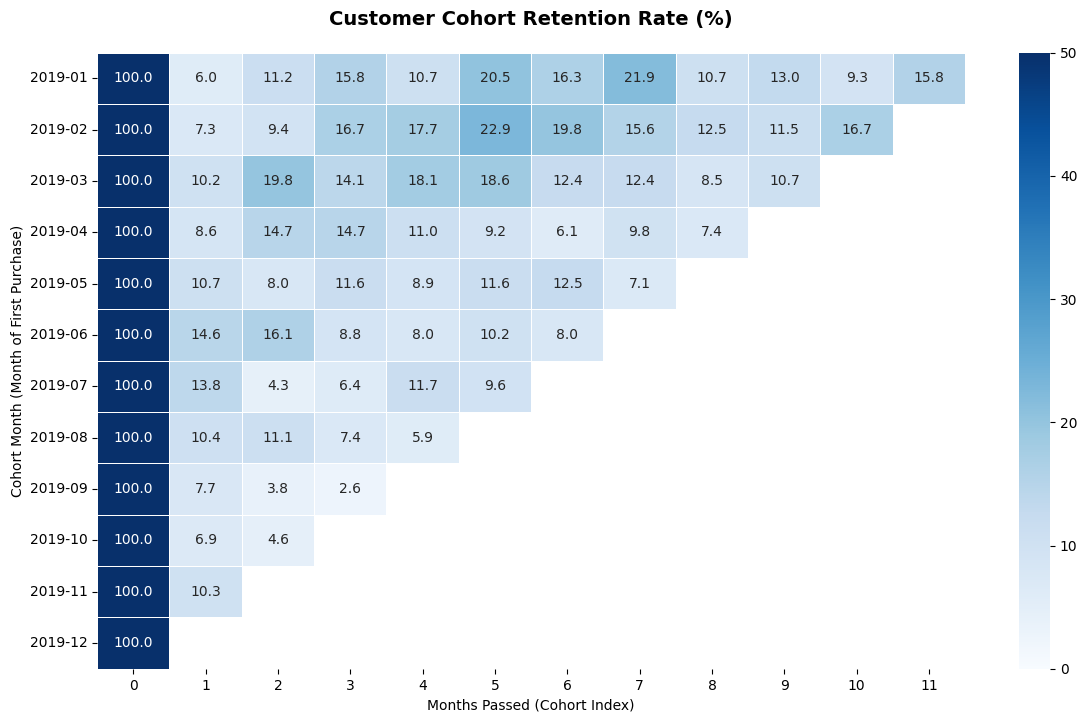

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt


analysis_set['Transaction_Month'] = analysis_set['Transaction_Date'].dt.to_period('M')
analysis_set['Cohort_Month'] = analysis_set.groupby('CustomerID')['Transaction_Date'].transform('min').dt.to_period('M')


def get_month_diff(df):
    years_diff = df['Transaction_Month'].dt.year - df['Cohort_Month'].dt.year
    months_diff = df['Transaction_Month'].dt.month - df['Cohort_Month'].dt.month
    return years_diff * 12 + months_diff

analysis_set['Cohort_Index'] = get_month_diff(analysis_set)


cohort_data = analysis_set.groupby(['Cohort_Month', 'Cohort_Index'])['CustomerID'].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index='Cohort_Month', columns='Cohort_Index', values='CustomerID')


cohort_sizes = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0) * 100
retention_matrix = retention_matrix.round(1)


plt.figure(figsize=(14, 8))
sns.heatmap(
    retention_matrix,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    vmin=0, vmax=50,
    linewidths=.5
)

plt.title('Customer Cohort Retention Rate (%)', weight='bold', fontsize=14, pad=20)
plt.ylabel('Cohort Month (Month of First Purchase)')
plt.xlabel('Months Passed (Cohort Index)')
plt.show()


# Final Conclusions

## 1. Data Preparation

**Action:** Cleaned and prepared the transactional dataset by handling missing values, correcting data types, and creating additional analytical features.

**Result:** A structured and reliable dataset was created for further statistical analysis, visualization, forecasting, and machine learning.

**Insight:** High-quality data preprocessing improves the reliability of all subsequent analyses and predictive models.

---

## 2. Exploratory Data Analysis

**Action:** Explored customer transactions, sales performance, and purchasing behavior using descriptive statistics and visualizations.

**Result:** Key business patterns, customer activity, revenue distribution, and purchasing trends were identified.

**Insight:** Exploratory analysis provides the foundation for understanding customer behavior and identifying opportunities for business improvement.

---

## 3. Cohort Analysis

**Action:** Grouped customers into cohorts based on their first purchase month and measured retention over time.

**Result:** Customer retention declined gradually after the first purchase, with the highest retention observed during the initial months of customer activity.

**Insight:** The business should prioritize customer engagement immediately after the first purchase to maximize long-term retention and customer lifetime value.

---

## 4. Discount Analysis

**Action:** Analyzed the relationship between discount usage, purchasing behavior, and sales performance.

**Result:** Discounts influenced customer purchasing behavior, although larger discounts did not always translate into higher business performance.

**Insight:** Promotional campaigns should be optimized to balance customer acquisition with profitability instead of relying solely on larger discounts.

---

## 5. Marketing Analysis

**Action:** Evaluated customer purchasing behavior in relation to marketing campaigns and promotional activities.

**Result:** Marketing-related variables showed measurable relationships with customer spending and purchasing frequency.

**Insight:** Marketing effectiveness should be continuously monitored using customer behavior metrics to maximize return on investment.

---

## 6. Statistical Analysis

**Action:** Performed normality tests and selected appropriate statistical methods to evaluate relationships between business variables.

**Result:** Several statistically significant relationships between customer behavior and business metrics were identified.

**Insight:** Business decisions should be supported by statistically validated relationships rather than relying only on descriptive observations.

---

## 7. RFM Segmentation

**Action:** Segmented customers using Recency, Frequency, and Monetary analysis.

**Result:** Distinct customer groups were identified, including loyal high-value customers and inactive or low-value customers.

**Insight:** Customer segmentation enables personalized marketing strategies that improve retention, customer satisfaction, and marketing efficiency.

---

## 8. Revenue Forecasting

**Action:** Compared multiple time series forecasting models to predict future daily revenue.

**Result:** Forecasting models were evaluated using performance metrics, allowing the most accurate model to be selected.

**Insight:** Reliable revenue forecasting improves budgeting, inventory planning, and long-term business strategy.

---

## 9. Customer Lifetime Analysis

**Action:** Analyzed customer purchasing timelines using first purchase date, last purchase date, and transaction history.

**Result:** Considerable differences in customer lifetime and purchasing frequency were observed across the customer base.

**Insight:** Understanding customer lifetime helps identify loyal customers, estimate future revenue potential, and prioritize retention efforts.

---

## 10. Machine Learning

**Action:** Built and evaluated a Random Forest classifier to predict repeat customer purchases.

**Result:** The model successfully identified customers who were more likely to make future purchases based on historical behavioral data.

**Insight:** Predictive analytics enables proactive customer retention by identifying customers who should receive personalized marketing campaigns before becoming inactive.

---

# Overall Conclusion

This project demonstrates a complete end-to-end customer analytics workflow, covering data preparation, exploratory data analysis, cohort analysis, statistical testing, customer segmentation, revenue forecasting, and machine learning.

The analysis revealed valuable insights into customer retention, purchasing behavior, discount effectiveness, marketing performance, and revenue dynamics. Statistical methods validated important business relationships, while predictive models demonstrated how historical customer data can be used to forecast future customer behavior.

Overall, this project illustrates how Python, statistical analysis, data visualization, time series forecasting, and machine learning can transform raw transactional data into actionable business insights that support data-driven decision-making, improve customer retention strategies, optimize marketing efforts, and enhance long-term business performance.

# Final Takeaway

This project demonstrates the practical application of modern data analytics techniques to solve real business problems. By combining exploratory analysis, statistical testing, customer segmentation, forecasting, and machine learning, the analysis provides a comprehensive understanding of customer behavior and delivers actionable recommendations that can improve customer retention, marketing effectiveness, and overall business performance.